# 🎙️ Grammar Scoring Engine for Spoken English (v3)

**Task:** given a 45–60 s audio clip of a person speaking, predict their **grammar score** on the 0–5 MOS Likert rubric.
**Metrics:** RMSE (lower is better) and Pearson correlation (higher is better).

---

## 📄 Report (summary)

### 1. Approach in one paragraph
Grammar is a property of *what* is said, but recordings also carry strong cues of *how* it is said. Research on automated
speaking assessment (Bannò & Matassoni 2022; Speak & Improve Challenge 2025; Ma et al. 2025) shows that **self-supervised
speech encoders (WavLM / Whisper encoder) and speech LLMs beat transcript-only systems**, and that **fusing audio + text + interpretable
features** is best. We therefore build three complementary branches, train small, well-regularised regressors on each
(only 732 usable training clips), combine them with a **non-negative stacking** layer and a **CV-selected calibration**.

**New in v2** (driven by the error analysis of v1 and by the strongest public solutions):
* **LLM rubric judge**: Qwen2.5-7B-Instruct reads the transcript together with the official rubric and gives the
  probability of each score 1–5; the same forward pass provides rubric-conditioned **text-LLM embeddings**.
  This targets v1's main weakness (fluent speakers with weak grammar scored too high).
* **w2v-BERT 2.0**, a fourth speech encoder pre-trained on 4.5 M hours of audio.
* **Layer windows**: each encoder uses the best layer or the average of its neighbouring layers, chosen by CV.
* **Speaker prior**: test clips whose speaker also appears in the training data are blended with that speaker's known
  scores; the blend weight is estimated on training clips of repeated speakers.

**New in v3:**
* **Anchored LLM judge (Qwen3-14B)**: a stronger LLM sees the rubric *plus* four scored example transcripts (one per
  score level) before judging; this is the "anchor" technique that makes LLM essay scoring much more reliable.
* **Grammatical error correction (CoEdIT)**: every sentence is corrected by a GEC model; the word-level edit rate is a
  direct, interpretable count of grammar errors.
* **Ordinal heads**: besides Ridge and SVR, each view gets a classifier over the half-point score levels whose expected
  value is the prediction (the "fair average" idea of Ma et al., 2025), adding model diversity to the stack.
* **Second ASR without "clean-up" (wav2vec2 CTC)**: how far Whisper's fluent transcript is from a raw, letter-level
  transcript measures how much Whisper had to repair.
* **Stronger modelling**: SVR `C` tuned per view, KNN heads for diversity, and **ensemble selection** (Caruana et al.,
  2004) competing with non-negative stacking, chosen by nested CV.
* **Feature store**: all extracted features are saved to `/kaggle/working/features`. Attaching this notebook's output as an
  input makes later runs reuse them, so experiments take minutes instead of hours.

### 2. Pipeline architecture
```
                              Audio .wav (45-60 s, 16 kHz mono)
                                           │
                    ┌──────────────────────▼──────────────────────┐
                    │ PREPROCESSING: DC removal, silence trim,    │
                    │ peak normalisation, zero-score detection,   │
                    │ speaker clustering → speaker-grouped CV     │
                    └──────────────────────┬──────────────────────┘
          ┌────────────────────────────────┼────────────────────────────────┐
          ▼                                ▼                                ▼
 ┌──────────────────┐           ┌─────────────────────┐          ┌─────────────────────┐
 │ A. AUDIO EMBED.  │           │ B. ASR → TEXT EMBED.│          │ C. HANDCRAFTED      │
 │ WavLM  (all lyrs)│           │ Whisper, prompted to│          │ LanguageTool errors │
 │ Whisper encoder  │           │ keep fillers/errors │          │ GPT-2 perplexity    │
 │ Qwen2-Audio LLM  │           │ RoBERTa (all layers)│          │ CoLA acceptability  │
 │ w2v-BERT 2.0     │           │ Qwen2.5-7B states   │          │ LLM rubric judge    │
 │ best layer by CV │           │ best layer by CV    │          │ fluency & pauses    │
 └────────┬─────────┘           └──────────┬──────────┘          └──────────┬──────────┘
          ▼                                ▼                                ▼
     SVR + Ridge                      Ridge + SVR                   Ridge + GradBoost
          └──────────── out-of-fold predictions (5-fold × 3 seeds, speaker-grouped) ───┘
                                           ▼
                        Non-negative linear stacking
                                           ▼
                Score-aware calibration (none / stretch / isotonic, chosen by CV)
                                           ▼
          speaker prior for known speakers  +  zero-score batch → 0
                                           ▼
                                    submission.csv
```

### 3. Key preprocessing decisions
| Finding | Decision |
|---|---|
| 37 training clips are labelled **0** (outside the 1–5 rubric). They contain normal amounts of speech, but form a separate batch that is perfectly recognisable from recording / ASR characteristics | Removed from regressor training; a separate **zero-score detector** maps such clips to 0 |
| The same speakers appear several times with near-identical scores | **Speaker-grouped** cross-validation (clusters of speaker embeddings), otherwise CV is over-optimistic |
| Whisper normally "cleans up" disfluent speech, hiding grammar errors | Whisper is **prompted with a disfluent, ungrammatical example** so it keeps fillers, repetitions and errors |
| `sample_submission.csv` lists stale IDs (only 25 of 204 match `test.csv`) | Submission is built from the **216 files in `test.csv`** |
| About 1 in 9 test clips comes from a speaker who is also in the training data | **Speaker prior** for those clips (Section 9.1) |

### 4. Evaluation
* **Training RMSE** (compulsory): models refit on the full training set and scored on it (in-sample, optimistic).
* **Cross-validated RMSE / Pearson** (honest): out-of-fold predictions from speaker-grouped 5-fold CV, repeated with 3 seeds.
* Ablations (each branch alone vs. stacked), layer-wise probing curves, residual analysis and feature correlations explain *why* the model works.

➡️ **All final numbers are printed in Section 12 (Results summary).**

---

## 0. Setup
Built for a **Kaggle notebook with a T4 GPU**: Settings → Accelerator **GPU T4**, Internet **ON**, then
**Save Version → Save & Run All (Commit)** (about 4 hours the first time). To iterate quickly afterwards: in a new
version, **Add Input → this notebook's output**; all features are then loaded from `features/` and a run takes ~15 minutes. `submission.csv` then appears in the version's **Output** tab.
On a machine without GPU the notebook still runs, with smaller models and without the audio LLM.

In [1]:
# Install the packages that Kaggle / Colab do not have, plus Java for LanguageTool
import importlib.util, subprocess, sys, shutil
for pkg, mod in [("faster-whisper", "faster_whisper"), ("language_tool_python", "language_tool_python"),
                 ("librosa", "librosa"), ("soundfile", "soundfile")] + \
                ([("bitsandbytes", "bitsandbytes")] if shutil.which("nvidia-smi") else []):   # 4-bit audio LLM
    if importlib.util.find_spec(mod) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)
if shutil.which("java") is None and shutil.which("apt-get"):
    subprocess.run("apt-get -qq update && apt-get -qq install -y openjdk-17-jre-headless > /dev/null",
                   shell=True, check=False)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.0/35.0 MB 62.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.6/39.6 MB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 80.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.2/63.2 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 48.2 MB/s eta 0:00:00


In [2]:
import os, re, gc, glob, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import soundfile as sf
import librosa
import librosa.display
import torch
from tqdm.auto import tqdm
from scipy.stats import pearsonr, spearmanr
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeCV, LinearRegression, LogisticRegression
from sklearn.svm import SVR
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold, cross_val_predict
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsRegressor
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.metrics import mean_squared_error, mean_absolute_error, roc_auc_score

import transformers
warnings.filterwarnings("ignore")
transformers.logging.set_verbosity_error()          # hide "LOAD REPORT" / unused-weight messages
os.environ["TOKENIZERS_PARALLELISM"] = "false"
sns.set_theme(style="whitegrid", palette="deep")

SEED = 42
SEEDS = [42, 7, 2026]                     # repeated CV seeds
SR = 16_000                               # target sample rate
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
GPU = DEVICE == "cuda"
DTYPE = torch.float16 if GPU else torch.float32
np.random.seed(SEED); torch.manual_seed(SEED)

# Model choices: large on GPU, light on CPU
CFG = dict(
    asr_model   = "large-v3" if GPU else "small.en",          # faster-whisper
    asr_compute = "float16" if GPU else "int8",
    asr_beam    = 5 if GPU else 1,
    wavlm       = "microsoft/wavlm-large" if GPU else "microsoft/wavlm-base-plus",
    whisper_enc = "openai/whisper-large-v3" if GPU else "openai/whisper-base",
    text_enc    = "roberta-large" if GPU else "roberta-base",
    spk_model   = "microsoft/wavlm-base-plus-sv",              # speaker verification x-vectors
    lm          = "gpt2",                                      # perplexity
    cola        = "textattack/roberta-base-CoLA",              # grammatical acceptability
    audio_llm   = "Qwen/Qwen2-Audio-7B-Instruct",              # speech LLM (GPU only, loaded in 4-bit)
    audio_llm_4bit = True,
    w2vbert     = "facebook/w2v-bert-2.0",                     # 600M speech encoder
    text_llm    = "Qwen/Qwen2.5-7B-Instruct" if GPU else "Qwen/Qwen2.5-0.5B-Instruct",   # rubric judge, 4-bit
    judge_llm   = "Qwen/Qwen3-14B" if GPU else "Qwen/Qwen3-0.6B",                      # anchored judge, 4-bit
    gec         = "grammarly/coedit-large" if GPU else "jbochi/coedit-small",          # grammatical error correction
    ctc         = "facebook/wav2vec2-large-960h-lv60-self" if GPU else "facebook/wav2vec2-base-960h",  # raw ASR
    use_audio_llm  = GPU,                                      # 7B model: skipped on CPU
    n_folds     = 5,
)
print(f"device = {DEVICE}"); print(CFG)

device = cuda
{'asr_model': 'large-v3', 'asr_compute': 'float16', 'asr_beam': 5, 'wavlm': 'microsoft/wavlm-large', 'whisper_enc': 'openai/whisper-large-v3', 'text_enc': 'roberta-large', 'spk_model': 'microsoft/wavlm-base-plus-sv', 'lm': 'gpt2', 'cola': 'textattack/roberta-base-CoLA', 'audio_llm': 'Qwen/Qwen2-Audio-7B-Instruct', 'audio_llm_4bit': True, 'w2vbert': 'facebook/w2v-bert-2.0', 'text_llm': 'Qwen/Qwen2.5-7B-Instruct', 'judge_llm': 'Qwen/Qwen3-14B', 'gec': 'grammarly/coedit-large', 'ctc': 'facebook/wav2vec2-large-960h-lv60-self', 'use_audio_llm': True, 'n_folds': 5}


### 📂 Paths
All input and output locations in one place. Inputs are the read-only competition files; outputs go to
`/kaggle/working` (shown in the Output tab).

**Feature store.** Every expensive feature (transcripts, embeddings, LLM judges …) is saved in `/kaggle/working/features`.
If the output of an earlier run of this notebook is attached as an input, features are loaded from there instead of
being recomputed. Model-level results (layer probing, CV fits) are always recomputed, in `/tmp`.

In [3]:
COMP_DIR    = "/kaggle/input/competitions/shl-hiring-assessment-2026"
DATA_DIR    = f"{COMP_DIR}/Dataset_Final"
TRAIN_CSV   = f"{DATA_DIR}/train.csv"
TEST_CSV    = f"{DATA_DIR}/test.csv"
SAMPLE_SUB  = f"{DATA_DIR}/sample_submission.csv"
TRAIN_AUDIO = f"{DATA_DIR}/train"
TEST_AUDIO  = f"{DATA_DIR}/test"
OUT_DIR     = "/kaggle/working"
FEATURE_DIR = f"{OUT_DIR}/features"                 # saved with the notebook version → reusable as an input
TMP_DIR     = "/tmp/gse_cache"                      # model-level results, recomputed every run

if not os.path.exists(COMP_DIR):                    # running outside Kaggle: use a local copy of the data
    DATA_DIR, OUT_DIR, FEATURE_DIR, TMP_DIR = "Dataset_Final", ".", "features", "cache_tmp"
    TRAIN_CSV, TEST_CSV, SAMPLE_SUB = (f"{DATA_DIR}/{f}" for f in ["train.csv", "test.csv", "sample_submission.csv"])
    TRAIN_AUDIO, TEST_AUDIO = f"{DATA_DIR}/train", f"{DATA_DIR}/test"
for d in [FEATURE_DIR, TMP_DIR]:
    os.makedirs(d, exist_ok=True)
INPUT_FEATURE_DIRS = sorted(glob.glob("/kaggle/input/**/features", recursive=True))   # earlier runs attached as input

for path in [TRAIN_CSV, TEST_CSV, TRAIN_AUDIO, TEST_AUDIO]:
    assert os.path.exists(path), f"missing: {path}"
print(f"data   : {DATA_DIR}  ({len(os.listdir(TRAIN_AUDIO))} train / {len(os.listdir(TEST_AUDIO))} test wav files)")
print(f"output : {OUT_DIR}   features: {FEATURE_DIR}   reused feature inputs: {INPUT_FEATURE_DIRS or 'none'}")

def feature_path(name):
    # Where a saved feature lives: an attached earlier run first, then this run's feature folder
    for d in INPUT_FEATURE_DIRS + [FEATURE_DIR]:
        p = os.path.join(d, f"{name}.pkl")
        if os.path.exists(p):
            return p
    return None

def cached(name, fn, shared=True):
    # shared=True: feature, saved to FEATURE_DIR and reused across runs; shared=False: model result, kept in /tmp
    path = feature_path(name) if shared else os.path.join(TMP_DIR, f"{name}.pkl")
    if path and os.path.exists(path):
        if shared and not path.startswith(FEATURE_DIR):
            print(f"  [{name}] loaded from {os.path.dirname(path)}")
        return pd.read_pickle(path)
    t0 = time.time(); out = fn()
    pd.to_pickle(out, os.path.join(FEATURE_DIR if shared else TMP_DIR, f"{name}.pkl"))
    print(f"  [{name}] computed in {(time.time()-t0)/60:.1f} min")
    return out

def free():
    gc.collect()
    if GPU: torch.cuda.empty_cache()

def safe(step, fn, fallback):
    # Optional feature step: if it fails (out of memory, download error …) the run continues without it,
    # so a 4-hour commit always reaches the submission cell
    try:
        return fn()
    except Exception as e:
        print(f"⚠️ {step} skipped: {repr(e)[:300]}")
        free()
        return fallback

def run_and_drop(fn, name):
    # Extract features with a large model, then delete its downloaded weights so Kaggle's disk does not fill up
    out = fn(name)
    try:
        from huggingface_hub import scan_cache_dir
        info = scan_cache_dir()
        revs = [r.commit_hash for repo in info.repos if repo.repo_id == name for r in repo.revisions]
        if revs:
            info.delete_revisions(*revs).execute()
    except Exception as e:
        print(f"could not delete cached weights of {name}: {e}")
    return out

data   : /kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final  (769 train / 216 test wav files)
output : /kaggle/working   features: /kaggle/working/features   reused feature inputs: none


## 1. Data loading & exploratory analysis

In [4]:
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)
sample_sub = pd.read_csv(SAMPLE_SUB)

train_df["path"] = train_df.filename.map(lambda f: os.path.join(TRAIN_AUDIO, f))
test_df["path"]  = test_df.filename.map(lambda f: os.path.join(TEST_AUDIO, f))

# One table for all clips: features are computed once for train + test
all_df = pd.concat([train_df.assign(split="train"), test_df.assign(split="test", label=np.nan)],
                   ignore_index=True)
info = [sf.info(p) for p in all_df.path]
all_df["duration"] = [i.duration for i in info]
all_df["sr"] = [i.samplerate for i in info]
TR = (all_df.split == "train").values
TE = ~TR

print(f"train: {TR.sum()} clips | test: {TE.sum()} clips | sample rates: {all_df.sr.unique()}")
print(f"sample_submission rows: {len(sample_sub)} | IDs matching test.csv: "
      f"{len(set(sample_sub.filename) & set(test_df.filename))}  → submission is built from test.csv")
all_df.head()

train: 769 clips | test: 216 clips | sample rates: [16000]
sample_submission rows: 204 | IDs matching test.csv: 25  → submission is built from test.csv


,filename,label,path,split,duration,sr
0,audio_192.wav,3.0,/kaggle/input/competitions/shl-hiring-assessme...,train,60.508375,16000
1,audio_436.wav,3.0,/kaggle/input/competitions/shl-hiring-assessme...,train,60.074688,16000
2,audio_447.wav,3.5,/kaggle/input/competitions/shl-hiring-assessme...,train,60.074688,16000
3,audio_126.wav,2.0,/kaggle/input/competitions/shl-hiring-assessme...,train,45.060000,16000
4,audio_61.wav,2.0,/kaggle/input/competitions/shl-hiring-assessme...,train,45.300000,16000


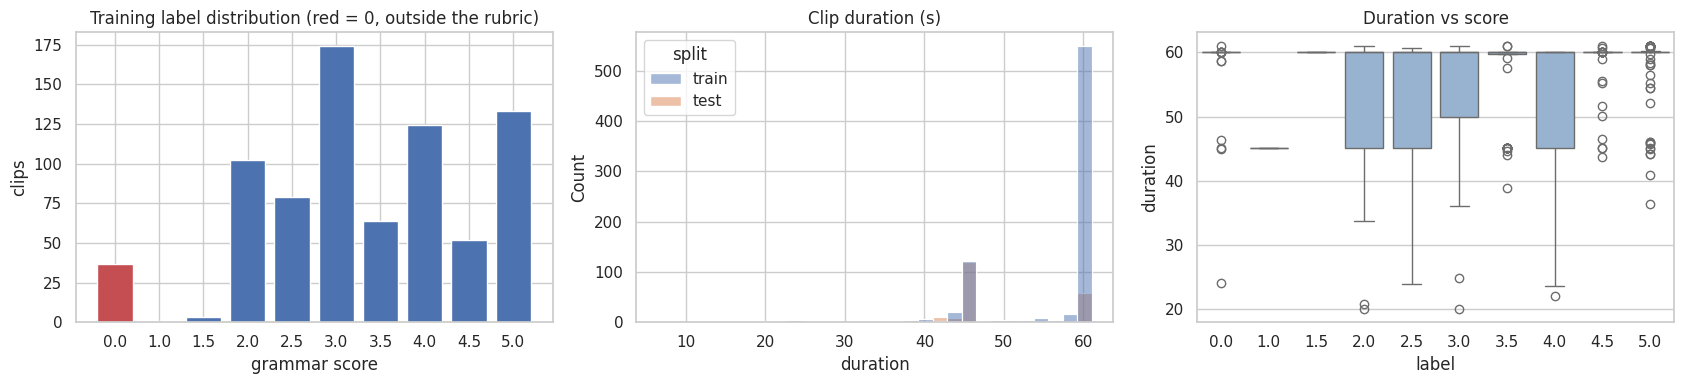

{'count': 769.0, 'mean': 3.313, 'std': 1.239, 'min': 0.0, '25%': 2.5, '50%': 3.0, '75%': 4.0, 'max': 5.0}


In [5]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4))
vc = train_df.label.value_counts().sort_index()
ax[0].bar(vc.index.astype(str), vc.values, color=["#c44e52" if v == 0 else "#4c72b0" for v in vc.index])
ax[0].set(title="Training label distribution (red = 0, outside the rubric)", xlabel="grammar score", ylabel="clips")
sns.histplot(data=all_df, x="duration", hue="split", bins=30, ax=ax[1])
ax[1].set(title="Clip duration (s)")
sns.boxplot(data=all_df[TR], x="label", y="duration", ax=ax[2], color="#8fb3d9")
ax[2].set(title="Duration vs score")
plt.tight_layout(); plt.show()
print(train_df.label.describe().round(3).to_dict())

**Observations**
* Scores cluster on 2–5; levels 1.0–1.5 are very rare (4 clips), so the model will be weakest at the bottom of the scale.
* 37 clips have score **0**, which is not part of the 1–5 rubric. They are not "worse than 1" grammar, so they are handled
  separately (Section 9) instead of distorting the regressor.

## 2. Audio preprocessing
For every clip: convert to mono, resample to 16 kHz if needed, remove DC offset, trim leading/trailing silence
(`top_db=35`) and peak-normalise. We also compute simple **acoustic / fluency descriptors** from the waveform
(speech fraction, number of speech segments, pause lengths, energy and spectral flatness). Flatness and speech fraction
help to recognise the zero-score batch (Section 9).

In [6]:
def load_audio(path):
    # Load → mono → 16 kHz → DC removal → trim silence → peak normalise
    y, sr = sf.read(path, dtype="float32", always_2d=False)
    if y.ndim > 1:
        y = y.mean(axis=1)
    if sr != SR:
        y = librosa.resample(y, orig_sr=sr, target_sr=SR)
    y = y - y.mean()
    yt, _ = librosa.effects.trim(y, top_db=35)
    if len(yt) > SR // 2:          # keep the untrimmed signal for (near-)silent clips
        y = yt
    peak = np.abs(y).max()
    return (y / peak * 0.95).astype(np.float32) if peak > 0 else y

def acoustic_features(y):
    # Speech/pause structure from an energy-based voice activity split
    dur = len(y) / SR
    iv = librosa.effects.split(y, top_db=30, frame_length=1024, hop_length=256)
    seg_len = (iv[:, 1] - iv[:, 0]) / SR if len(iv) else np.array([0.0])
    gaps = (iv[1:, 0] - iv[:-1, 1]) / SR if len(iv) > 1 else np.array([0.0])
    rms = librosa.feature.rms(y=y)[0]
    flat = librosa.feature.spectral_flatness(y=y)[0]
    zcr = librosa.feature.zero_crossing_rate(y)[0]
    return dict(
        dur_trimmed=dur, speech_fraction=seg_len.sum() / max(dur, 1e-3), n_segments=len(iv),
        mean_segment=seg_len.mean(), mean_gap=gaps.mean(), max_gap=gaps.max(),
        long_gaps_per_min=(gaps > 1.0).sum() / max(dur / 60, 1e-3),
        rms_mean=rms.mean(), rms_std=rms.std(), flatness_mean=flat.mean(), zcr_mean=zcr.mean())

acoustic = cached("acoustic", lambda: pd.DataFrame(
    [acoustic_features(load_audio(p)) for p in tqdm(all_df.path, desc="acoustic")]))
acoustic.describe().T.round(3)

acoustic:   0%|          | 0/985 [00:00<?, ?it/s]

  [acoustic] computed in 1.9 min


,count,mean,std,min,25%,50%,75%,max
dur_trimmed,985.0,52.113,8.466,5.536,44.928,56.416,58.955,61.035
speech_fraction,985.0,0.701,0.152,0.037,0.616,0.695,0.772,1.000
n_segments,985.0,64.553,29.480,1.000,51.000,67.000,84.000,211.000
mean_segment,985.0,4.589,13.785,0.133,0.417,0.519,0.671,61.035
mean_gap,985.0,0.238,0.174,0.000,0.147,0.217,0.298,2.912
max_gap,985.0,1.935,1.835,0.000,0.928,1.488,2.480,23.456
long_gaps_per_min,985.0,3.219,3.343,0.000,0.000,2.184,5.139,16.879
rms_mean,985.0,0.059,0.024,0.005,0.044,0.055,0.070,0.168
rms_std,985.0,0.050,0.015,0.006,0.041,0.049,0.058,0.113
flatness_mean,985.0,0.053,0.091,0.000,0.018,0.029,0.047,0.523


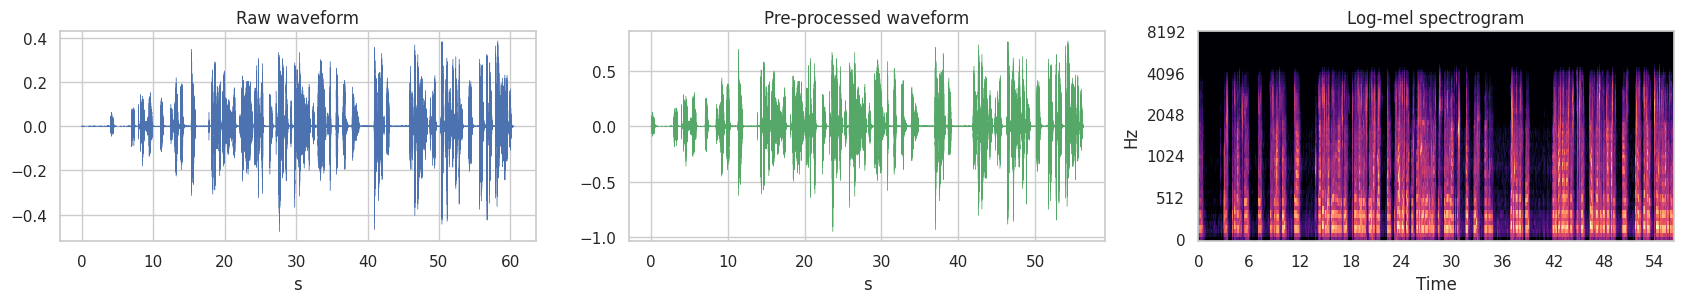

In [7]:
# Visual check of preprocessing on one clip
y_raw, _ = sf.read(all_df.path[0], dtype="float32")
y_pp = load_audio(all_df.path[0])
fig, ax = plt.subplots(1, 3, figsize=(17, 3.2))
ax[0].plot(np.arange(len(y_raw)) / SR, y_raw, lw=0.3); ax[0].set(title="Raw waveform", xlabel="s")
ax[1].plot(np.arange(len(y_pp)) / SR, y_pp, lw=0.3, color="#55a868"); ax[1].set(title="Pre-processed waveform", xlabel="s")
S = librosa.power_to_db(librosa.feature.melspectrogram(y=y_pp, sr=SR, n_mels=64), ref=np.max)
librosa.display.specshow(S, sr=SR, x_axis="time", y_axis="mel", ax=ax[2]); ax[2].set(title="Log-mel spectrogram")
plt.tight_layout(); plt.show()

## 3. Speaker clustering → speaker-grouped cross-validation
Several training clips come from the **same speaker** and receive near-identical scores. With a random split, the model can
recognise the voice and look better than it really is. We extract speaker-verification x-vectors (`wavlm-base-plus-sv`),
centre them, cluster them with cosine distance, and use the clusters as **groups** in `StratifiedGroupKFold`, so a speaker
never appears in both the training and validation folds. The same-speaker threshold is not guessed: it is calibrated on
the data as the voice similarity above which pairs of clips get (almost) the same score.

In [8]:
from transformers import AutoFeatureExtractor, WavLMForXVector

def speaker_embeddings():
    fe = AutoFeatureExtractor.from_pretrained(CFG["spk_model"])
    model = WavLMForXVector.from_pretrained(CFG["spk_model"]).to(DEVICE).eval()
    out = []
    for p in tqdm(all_df.path, desc="speaker x-vectors"):
        y = load_audio(p)[: 20 * SR]                     # 20 s is plenty for speaker identity
        inp = fe(y, sampling_rate=SR, return_tensors="pt").to(DEVICE)
        with torch.no_grad():
            e = model(**inp).embeddings[0]
        out.append(torch.nn.functional.normalize(e, dim=-1).cpu().numpy())
    del model; free()
    return np.stack(out)

SPK = cached("speaker_xvectors", speaker_embeddings)

# Raw x-vectors share a strong common direction (random pairs of different people often have cosine > 0.9),
# so they are centred first; after centring, different speakers are roughly uncorrelated.
SPKc = SPK - SPK.mean(0)
SPKc /= np.linalg.norm(SPKc, axis=1, keepdims=True)
S = SPKc @ SPKc.T

# Calibrate the same-speaker threshold with the labels: clips of one speaker get almost the same score, random
# pairs do not. SIM_T = lowest similarity t such that all pairs with similarity >= t disagree by at most half
# of what random pairs disagree.
lab_idx = np.where(TR & (all_df.label > 0).values)[0]
iu = np.triu_indices(len(lab_idx), 1)
pair_sim = S[np.ix_(lab_idx, lab_idx)][iu]
lab = all_df.label.values[lab_idx]
pair_diff = np.abs(lab[:, None] - lab[None, :])[iu]
RANDOM_DIFF = pair_diff.mean()
SIM_CURVE = pd.DataFrame([dict(t=t, n_pairs=(pair_sim >= t).sum(), mean_abs_diff=pair_diff[pair_sim >= t].mean())
                          for t in np.arange(0.30, 0.96, 0.01) if (pair_sim >= t).sum() >= 5])
ok = SIM_CURVE[SIM_CURVE.mean_abs_diff <= 0.5 * RANDOM_DIFF]
SIM_T = float(np.clip(ok.t.min(), 0.5, 0.95)) if len(ok) else 0.75     # fallback if too few pairs

clusters = AgglomerativeClustering(n_clusters=None, distance_threshold=1 - SIM_T,
                                   metric="cosine", linkage="average").fit_predict(SPKc)
all_df["speaker"] = clusters
print(f"same-speaker similarity threshold: {SIM_T:.2f} (random-pair |score diff| = {RANDOM_DIFF:.2f})")
tr_spk = all_df.loc[TR, "speaker"]
print(f"speaker clusters in train: {tr_spk.nunique()} for {TR.sum()} clips | "
      f"test clips whose speaker also appears in train: {all_df.loc[TE, 'speaker'].isin(tr_spk).mean():.1%}")

preprocessor_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/58.6k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  405MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  404MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/266 [00:00<?, ?it/s]

speaker x-vectors:   0%|          | 0/985 [00:00<?, ?it/s]

  [speaker_xvectors] computed in 2.8 min
same-speaker similarity threshold: 0.91 (random-pair |score diff| = 1.15)
speaker clusters in train: 486 for 769 clips | test clips whose speaker also appears in train: 11.6%


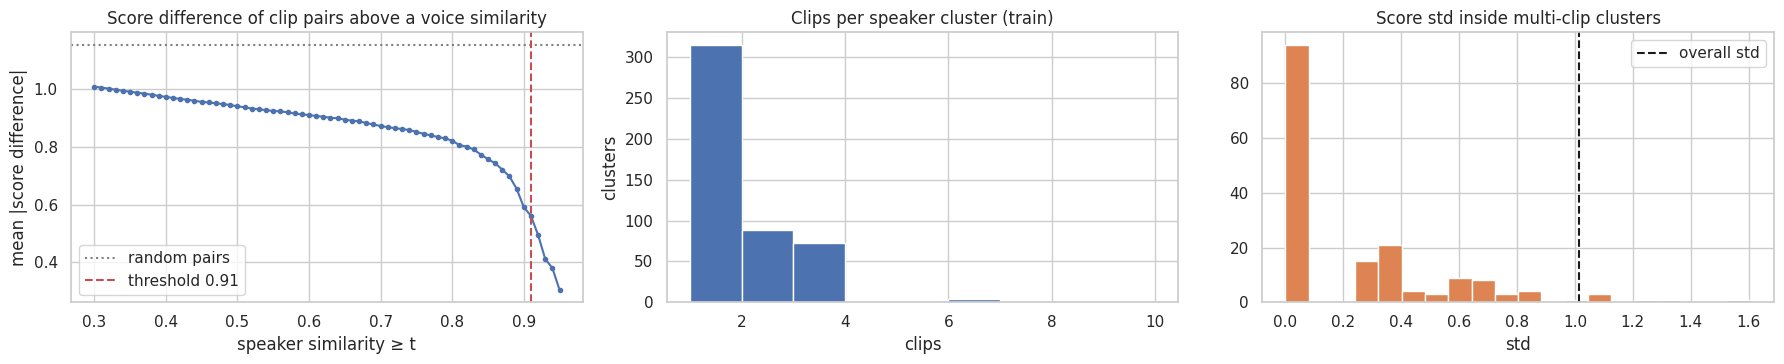

mean within-speaker std: 0.238 vs overall std: 1.014 | largest cluster: 9 clips


In [9]:
# Do repeated speakers really get the same score?
g = all_df[TR & (all_df.label > 0)].groupby("speaker").label
multi = g.filter(lambda s: len(s) > 1).groupby(all_df.speaker).agg(["size", "std"])
fig, ax = plt.subplots(1, 3, figsize=(18, 3.8))
ax[0].plot(SIM_CURVE.t, SIM_CURVE.mean_abs_diff, marker=".")
ax[0].axhline(RANDOM_DIFF, color="grey", ls=":", label="random pairs")
ax[0].axvline(SIM_T, color="r", ls="--", label=f"threshold {SIM_T:.2f}")
ax[0].set(title="Score difference of clip pairs above a voice similarity", xlabel="speaker similarity ≥ t",
          ylabel="mean |score difference|"); ax[0].legend()
sizes = all_df.loc[TR, "speaker"].value_counts()
ax[1].hist(sizes, bins=range(1, sizes.max() + 2), color="#4c72b0")
ax[1].set(title="Clips per speaker cluster (train)", xlabel="clips", ylabel="clusters")
if len(multi):
    ax[2].hist(multi["std"], bins=20, color="#dd8452")
ax[2].axvline(all_df.loc[TR & (all_df.label > 0), "label"].std(), color="k", ls="--", label="overall std")
ax[2].set(title="Score std inside multi-clip clusters", xlabel="std"); ax[2].legend()
plt.tight_layout(); plt.show()
print(f"mean within-speaker std: {multi['std'].mean():.3f} vs overall std: "
      f"{all_df.loc[TR & (all_df.label > 0), 'label'].std():.3f} | largest cluster: {sizes.max()} clips")

## 4. Speech recognition (Whisper)
`faster-whisper` transcribes each pre-processed clip with **word timestamps and word confidences**.

Whisper tends to *normalise* learner speech: it drops "um/uh", repetitions and even fixes grammar, which hides exactly the
errors we want to score. Following the spoken-GEC literature, we pass an **initial prompt that is itself disfluent and
ungrammatical**, which biases the decoder towards a verbatim transcript. Silero VAD skips silence and
`condition_on_previous_text=False` prevents repetition loops.

In [10]:
from faster_whisper import WhisperModel as FasterWhisper

VERBATIM_PROMPT = ("Um, so I, uh, I go to the market yesterday and, like, I buyed some... some vegetable. "
                   "Hmm, it were very crowded, you know, and and I am not finding the the thing.")

def transcribe_all():
    try:
        asr = FasterWhisper(CFG["asr_model"], device=DEVICE, compute_type=CFG["asr_compute"])
    except Exception as e:      # e.g. CUDA/cuDNN mismatch → fall back to CPU
        print("GPU ASR failed, falling back to CPU small.en:", e)
        asr = FasterWhisper("small.en", device="cpu", compute_type="int8")
    rows = []
    for p in tqdm(all_df.path, desc="ASR"):
        segs, _ = asr.transcribe(load_audio(p), language="en", beam_size=CFG["asr_beam"],
                                 vad_filter=True, word_timestamps=True,
                                 condition_on_previous_text=False, initial_prompt=VERBATIM_PROMPT)
        segs = list(segs)
        rows.append(dict(
            text=" ".join(s.text.strip() for s in segs).strip(),
            words=[(w.start, w.end, w.word.strip(), w.probability) for s in segs for w in (s.words or [])],
            avg_logprob=np.mean([s.avg_logprob for s in segs]) if segs else -3.0,
            no_speech_prob=np.mean([s.no_speech_prob for s in segs]) if segs else 1.0,
            compression_ratio=np.mean([s.compression_ratio for s in segs]) if segs else 0.0))
    del asr; free()
    return pd.DataFrame(rows)

asr = cached("asr", transcribe_all)
all_df["text"] = asr.text.values
# Example transcripts at different score levels
for lvl in [2.0, 3.0, 4.0, 5.0]:
    r = all_df[TR & (all_df.label == lvl)].head(1)
    if len(r):
        print(f"--- score {lvl} ---\n{r.text.iloc[0][:400]}\n")

ASR:   0%|          | 0/985 [00:00<?, ?it/s]

  [asr] computed in 57.7 min
--- score 2.0 ---
Once upon a time, we, with five friends, went on a tour, went on a deep tour with a travel agent on a Manali, and we stayed on a resort, and we stayed around, we stayed at a resort, and after that, in staying, when we checked in in the resort, after that, at night, we played with you, you know, you know, we played, and after that, we went on the floor top to the resort. see the night view of the c

--- score 3.0 ---
Well, this, the playground is very, very beautiful and fun. There are, there are playtools like the merry-go-round, the swing, the students usually enjoy the swing. It has to be, like, um, it's more like a game of pair, because one sits on it and the other person will have to push, and the merry-go-round, we just climb on it and Some of them play football, some park while others just keep swimming

--- score 4.0 ---
The school play... the school playground is very big and it's very colorful. It has a lot of games for kids and t

## 5. Handcrafted, interpretable features
Directly mirroring the rubric ("sentence structure", "basic mistakes", "incomplete sentences", "complex structures",
"self-correction"):

| Group | Features |
|---|---|
| Fluency (from word timestamps) | words/sec, articulation rate, pauses > 0.5 s / > 1 s, mean & max gap |
| Disfluency | filler ratio (um/uh/er…), immediate word repetitions |
| Lexical / syntactic complexity | type-token ratio, word length, sentence count & length, subordinating conjunctions |
| Grammar errors | **LanguageTool** matches per word (all / grammar category only) |
| Language-model fluency | **GPT-2** token negative log-likelihood (mean, std, p90) and perplexity |
| Grammatical acceptability | **RoBERTa-CoLA** probability that each sentence is acceptable (mean, min, share < 0.5) |
| ASR confidence | Whisper avg log-prob, no-speech prob, word-probability stats |

In [11]:
FILLERS = {"um", "uh", "umm", "uhh", "hmm", "er", "erm", "ah", "mm", "eh"}
SUBORD = {"because", "although", "though", "which", "who", "whom", "whose", "that", "when", "while", "if",
          "unless", "since", "whereas", "whether", "where", "after", "before", "until", "so"}

def split_sentences(text):
    return [s for s in re.split(r"(?<=[.!?])\s+", text.strip()) if len(s.split()) > 0]

def fluency_features(row, a):
    w = row.words
    toks = [re.sub(r"[^\w']", "", t[2].lower()) for t in w]
    keep = [i for i, t in enumerate(toks) if t]
    toks = [toks[i] for i in keep]
    n = len(toks)
    dur = max(a.dur_trimmed, 1e-3)
    f = dict(n_words=n, words_per_sec=n / dur, avg_logprob=row.avg_logprob,
             no_speech_prob=row.no_speech_prob, compression_ratio=row.compression_ratio)
    if n == 0:
        return f
    st = np.array([w[i][0] for i in keep]); en = np.array([w[i][1] for i in keep])
    pr = np.array([w[i][3] for i in keep])
    gaps = np.clip(st[1:] - en[:-1], 0, None) if n > 1 else np.zeros(1)
    sents = split_sentences(row.text)
    sent_len = [len(s.split()) for s in sents] or [0]
    f.update(
        articulation_rate=n / max((en - st).sum(), 1e-3),
        pauses_05_per_word=(gaps > 0.5).sum() / n, pauses_1_per_word=(gaps > 1.0).sum() / n,
        mean_word_gap=gaps.mean(), max_word_gap=gaps.max(),
        filler_ratio=sum(t in FILLERS for t in toks) / n,
        repetition_ratio=sum(toks[i] == toks[i - 1] for i in range(1, n)) / n,
        ttr=len(set(toks)) / n, root_ttr=len(set(toks)) / np.sqrt(n),
        mean_word_len=np.mean([len(t) for t in toks]),
        n_sentences=len(sents), mean_sent_len=np.mean(sent_len), max_sent_len=np.max(sent_len),
        subord_ratio=sum(t in SUBORD for t in toks) / n,
        word_prob_mean=pr.mean(), word_prob_p10=np.percentile(pr, 10), low_conf_ratio=(pr < 0.5).mean())
    return f

fluency = pd.DataFrame([fluency_features(r, a) for r, a in zip(asr.itertuples(), acoustic.itertuples())])
fluency.describe().T.round(3).head(10)

,count,mean,std,min,25%,50%,75%,max
n_words,985.0,102.801,26.823,8.000,84.000,103.000,123.000,181.000
words_per_sec,985.0,1.986,0.450,0.403,1.727,2.027,2.299,3.461
avg_logprob,985.0,-0.226,0.106,-1.432,-0.262,-0.205,-0.163,-0.063
no_speech_prob,985.0,0.087,0.090,0.001,0.026,0.056,0.120,0.587
compression_ratio,985.0,1.536,0.131,0.895,1.454,1.532,1.614,2.095
articulation_rate,985.0,2.342,0.431,1.095,2.051,2.342,2.613,4.666
pauses_05_per_word,985.0,0.025,0.026,0.000,0.009,0.019,0.035,0.286
pauses_1_per_word,985.0,0.015,0.022,0.000,0.000,0.009,0.020,0.238
mean_word_gap,985.0,0.061,0.078,0.000,0.024,0.038,0.067,1.083
max_word_gap,985.0,1.927,2.455,0.000,0.660,1.300,2.210,28.620


In [12]:
def languagetool_features():
    # Grammar error rates from LanguageTool (needs Java ≥ 17; skipped gracefully if unavailable)
    try:
        import language_tool_python
        tool = language_tool_python.LanguageTool("en-US")
    except Exception as e:
        print("LanguageTool unavailable → features set to NaN:", e)
        return pd.DataFrame({"lt_errors_per_word": [np.nan] * len(all_df), "lt_grammar_per_word": np.nan})
    rows = []
    for t in tqdm(all_df.text, desc="LanguageTool"):
        n = max(len(t.split()), 1)
        m = tool.check(t) if t else []
        cats = [str(getattr(x, "category", "")).upper() for x in m]
        rows.append(dict(lt_errors_per_word=len(m) / n,
                         lt_grammar_per_word=sum(c == "GRAMMAR" for c in cats) / n))
    tool.close()
    return pd.DataFrame(rows)

lt = cached("languagetool", languagetool_features)
lt.describe().T.round(4)

LanguageTool:   0%|          | 0/985 [00:00<?, ?it/s]

  [languagetool] computed in 1.1 min


,count,mean,std,min,25%,50%,75%,max
lt_errors_per_word,985.0,0.0258,0.0222,0.0,0.0101,0.0211,0.0374,0.1806
lt_grammar_per_word,985.0,0.0042,0.0076,0.0,0.0000,0.0000,0.0083,0.0504


In [13]:
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoModelForSequenceClassification

def lm_features():
    # GPT-2 token-level surprisal: ungrammatical word sequences are less probable
    tok = AutoTokenizer.from_pretrained(CFG["lm"])
    lm = AutoModelForCausalLM.from_pretrained(CFG["lm"]).to(DEVICE).eval()
    rows = []
    for t in tqdm(all_df.text, desc="GPT-2"):
        ids = tok(t or ".", return_tensors="pt", truncation=True, max_length=1024).input_ids.to(DEVICE)
        if ids.shape[1] < 2:
            rows.append(dict(lm_nll_mean=np.nan, lm_nll_std=np.nan, lm_nll_p90=np.nan, lm_ppl=np.nan)); continue
        with torch.no_grad():
            logits = lm(ids).logits[0, :-1].float()
        nll = torch.nn.functional.cross_entropy(logits, ids[0, 1:], reduction="none").cpu().numpy()
        rows.append(dict(lm_nll_mean=nll.mean(), lm_nll_std=nll.std(), lm_nll_p90=np.percentile(nll, 90),
                         lm_ppl=float(np.exp(nll.mean()))))
    del lm; free()
    return pd.DataFrame(rows)

def cola_features():
    # Probability that each sentence is grammatically acceptable (CoLA-finetuned RoBERTa; label 1 = acceptable)
    tok = AutoTokenizer.from_pretrained(CFG["cola"])
    clf = AutoModelForSequenceClassification.from_pretrained(CFG["cola"]).to(DEVICE).eval()
    rows = []
    for t in tqdm(all_df.text, desc="CoLA"):
        sents = split_sentences(t) or ["."]
        enc = tok(sents, return_tensors="pt", padding=True, truncation=True, max_length=128).to(DEVICE)
        with torch.no_grad():
            p = torch.softmax(clf(**enc).logits.float(), -1)[:, 1].cpu().numpy()
        rows.append(dict(cola_mean=p.mean(), cola_min=p.min(), cola_bad_share=(p < 0.5).mean()))
    del clf; free()
    return pd.DataFrame(rows)

lmf = cached("gpt2", lm_features)
cola = cached("cola", cola_features)

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  501MB            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors: downloading bytes:           |  0.00B            

CoLA:   0%|          | 0/985 [00:00<?, ?it/s]

  [cola] computed in 0.4 min


### 5.1 LLM rubric judge (Qwen2.5-7B-Instruct)
An instruction-tuned LLM reads the verbatim transcript together with the **official grammar rubric** and is asked for a
single digit. Instead of generating text, we read the probabilities of the next token being `1`…`5`
(one forward pass, no sampling) and use them, plus the expected score, as features. The same forward pass also returns
the LLM's hidden states, which become the **text-LLM embedding** branch in Section 6. The model is loaded in 4-bit.

config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

...

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

Qwen2.5-7B-Instruct:   0%|          | 0/985 [00:00<?, ?it/s]

  [text_llm] computed in 10.9 min


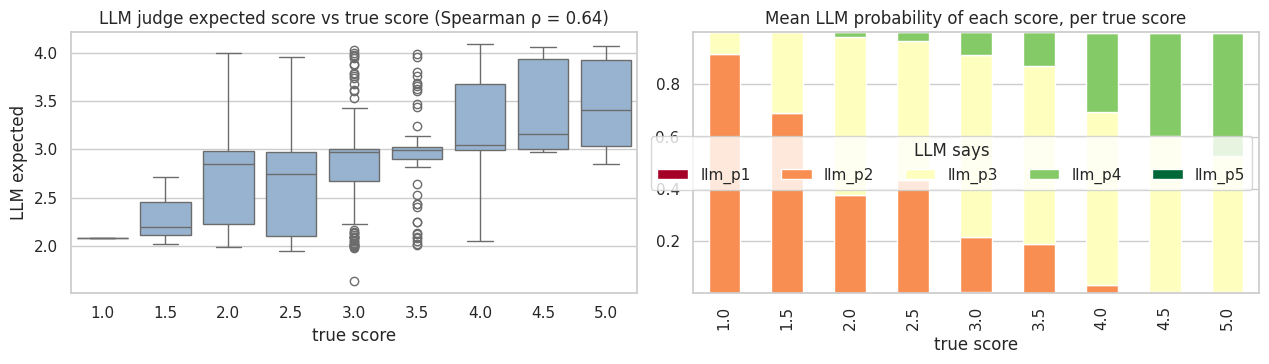

In [14]:
RUBRIC = '''Grammar score rubric (spoken English, 45-60 second answer):
1 = struggles with sentence structure and syntax; limited control over simple grammatical structures and memorised patterns.
2 = limited understanding of sentence structure; uses simple structures but consistently makes basic grammatical mistakes; may leave sentences incomplete.
3 = decent grasp of sentence structure but makes errors in grammatical structure, or decent grammar but errors in syntax.
4 = strong understanding of sentence structure and syntax; good control of grammar; occasional minor errors that do not cause misunderstanding; corrects most of them.
5 = high grammatical accuracy and adept control of complex grammar; seldom makes noticeable mistakes; handles complex structures well and self-corrects.'''

JUDGE_TEMPLATE = '''You are an expert examiner of spoken English.
{rubric}{anchors}

Below is an automatic, verbatim transcript of a candidate's spoken answer. Fillers (um, uh), repetitions and
false starts are kept on purpose. Judge ONLY grammar and sentence structure, not pronunciation, accent or content.

<transcript>
{transcript}
</transcript>

Answer with a single digit from 1 to 5.'''


def text_llm_features(name, anchors="", prefix="llm"):
    # One forward pass per transcript through an instruction-tuned LLM (Qwen2.5-7B-Instruct, 4-bit):
    #  * "rubric judge": probabilities of the next token being 1..5 after "Grammar score: " → expected score
    #  * hidden states of every layer, mean-pooled over the transcript tokens + the final (decision) token
    from transformers import AutoModelForCausalLM, BitsAndBytesConfig
    tok = AutoTokenizer.from_pretrained(name)
    kw = dict(dtype=torch.float16 if GPU else torch.float32)
    if GPU:
        kw.update(device_map="auto", quantization_config=BitsAndBytesConfig(
            load_in_4bit=True, bnb_4bit_quant_type="nf4", bnb_4bit_compute_dtype=torch.float16))
    model = AutoModelForCausalLM.from_pretrained(name, **kw).eval()
    dev = next(model.parameters()).device
    digit_ids = [tok.convert_tokens_to_ids(str(d)) for d in range(1, 6)]
    judge, embs = [], []
    for t in tqdm(all_df.text, desc=name.split("/")[-1]):
        t = t.strip() or "(no recognisable speech)"
        msgs = [{"role": "user", "content": JUDGE_TEMPLATE.format(rubric=RUBRIC, anchors=anchors, transcript=t)}]
        prompt = tok.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True,
                                         enable_thinking=False) + "Grammar score: "     # Qwen3: answer directly
        start = prompt.rindex(t)                                                       # the candidate, not an anchor
        enc = tok(prompt, return_tensors="pt", return_offsets_mapping=True)
        offs = enc.pop("offset_mapping")[0]
        span = ((offs[:, 0] >= start) & (offs[:, 1] <= start + len(t)) & (offs[:, 1] > offs[:, 0])).numpy()
        with torch.no_grad():
            out = model(**enc.to(dev), output_hidden_states=True)
        p = torch.softmax(out.logits[0, -1, digit_ids].float(), -1).cpu().numpy()
        judge.append({**{f"{prefix}_p{d}": p[d - 1] for d in range(1, 6)},
                      f"{prefix}_expected": float((p * np.arange(1, 6)).sum())})
        hs = torch.stack(out.hidden_states)[:, 0].float()                 # [layers, tokens, dim]
        span_t = torch.as_tensor(span, device=hs.device)
        body = hs[:, span_t].mean(1) if span.any() else hs.mean(1)
        embs.append(torch.cat([body, hs[:, -1]], -1).cpu().numpy().astype(np.float16))
    del model; free()
    return pd.DataFrame(judge), np.stack(embs)                            # judge features, [N, layers, 2*dim]

JUDGE, TEXT_LLM_EMB = safe("Qwen2.5 judge", lambda: cached("text_llm", lambda: run_and_drop(text_llm_features, CFG["text_llm"])),
                           (pd.DataFrame(index=all_df.index), None))

m = TR & (all_df.label > 0).values
if "llm_expected" in JUDGE:
    fig, ax = plt.subplots(1, 2, figsize=(14, 3.8))
    sns.boxplot(x=all_df.label[m].values, y=JUDGE.llm_expected[m].values, ax=ax[0], color="#8fb3d9")
    ax[0].set(title=f"LLM judge expected score vs true score (Spearman ρ = "
                    f"{spearmanr(JUDGE.llm_expected[m], all_df.label[m])[0]:.2f})", xlabel="true score", ylabel="LLM expected")
    JUDGE[[f"llm_p{d}" for d in range(1, 6)]][m].groupby(all_df.label[m].values).mean().plot.bar(stacked=True, ax=ax[1], cmap="RdYlGn")
    ax[1].set(title="Mean LLM probability of each score, per true score", xlabel="true score"); ax[1].legend(title="LLM says", ncol=5)
    plt.tight_layout(); plt.show()

### 5.2 Grammatical error correction (CoEdIT)
Each sentence of the transcript (fillers removed, so that "um/uh" are not counted as grammar errors) is corrected by
**CoEdIT**, an instruction-tuned grammatical-error-correction model. The word-level edit distance between the spoken and the
corrected sentence counts the grammar errors the candidate made:
`gec_edit_rate` (edits per word), `gec_changed_share` (share of sentences that needed a correction),
`gec_edits_per_sent`. These are direct, interpretable measurements of the rubric's "grammatical mistakes".

config.json:   0%|          | 0.00/787 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.50k [00:00<?, ?B/s]

spiece.model: reconstructing file:   0%|          |  0.00B /  792kB            

spiece.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/142 [00:00<?, ?B/s]

coedit-large:   0%|          | 0/985 [00:00<?, ?it/s]

  [gec] computed in 39.1 min
Spearman ρ with grammar score: {'gec_edit_rate': np.float64(-0.511), 'gec_changed_share': np.float64(-0.389), 'gec_edits_per_sent': np.float64(-0.409)}


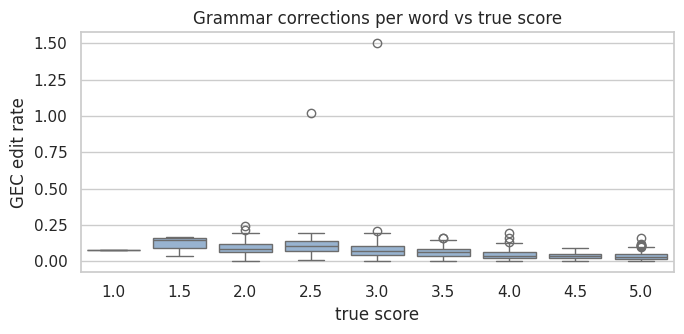

In [15]:
from transformers import AutoModelForSeq2SeqLM

def norm_words(s):
    return [w for w in re.sub(r"[^\w' ]", " ", s.lower()).split() if w not in FILLERS]

def word_edits(a, b):
    # Levenshtein distance between two word lists
    prev = list(range(len(b) + 1))
    for i, wa in enumerate(a, 1):
        cur = [i]
        for j, wb in enumerate(b, 1):
            cur.append(min(prev[j] + 1, cur[j - 1] + 1, prev[j - 1] + (wa != wb)))
        prev = cur
    return prev[-1]

def gec_features(name, batch=16):
    tok = AutoTokenizer.from_pretrained(name)
    model = AutoModelForSeq2SeqLM.from_pretrained(name).to(DEVICE).eval()   # fp32: T5 is unstable in fp16
    rows = []
    for t in tqdm(all_df.text, desc=name.split("/")[-1]):
        sents = [" ".join(norm_words(x)) for x in split_sentences(t)]
        sents = [x for x in sents if len(x.split()) >= 2][:40]
        if not sents:
            rows.append(dict(gec_edit_rate=np.nan, gec_changed_share=np.nan, gec_edits_per_sent=np.nan)); continue
        corrected = []
        for i in range(0, len(sents), batch):
            enc = tok([f"Fix grammatical errors in this sentence: {x}" for x in sents[i:i + batch]],
                      return_tensors="pt", padding=True, truncation=True, max_length=256).to(DEVICE)
            with torch.no_grad():
                out = model.generate(**enc, max_new_tokens=160, num_beams=1)
            corrected += tok.batch_decode(out, skip_special_tokens=True)
        edits = np.array([word_edits(a.split(), norm_words(b)) for a, b in zip(sents, corrected)])
        n = sum(len(a.split()) for a in sents)
        rows.append(dict(gec_edit_rate=edits.sum() / n, gec_changed_share=(edits > 0).mean(),
                         gec_edits_per_sent=edits.mean()))
    del model; free()
    return pd.DataFrame(rows)

GEC = safe("CoEdIT GEC", lambda: cached("gec", lambda: run_and_drop(gec_features, CFG["gec"])),
           pd.DataFrame(index=all_df.index))
m = TR & (all_df.label > 0).values
if "gec_edit_rate" in GEC:
    print("Spearman ρ with grammar score:",
          {c: round(spearmanr(GEC[c][m], all_df.label[m], nan_policy="omit")[0], 3) for c in GEC.columns})
    plt.figure(figsize=(7, 3.5))
    sns.boxplot(x=all_df.label[m].values, y=GEC.gec_edit_rate[m].values, color="#8fb3d9")
    plt.title("Grammar corrections per word vs true score"); plt.xlabel("true score"); plt.ylabel("GEC edit rate")
    plt.tight_layout(); plt.show()

### 5.3 Anchored LLM judge (Qwen3-14B)
A stronger LLM judges each transcript after seeing the rubric **and four scored example transcripts** (one each for scores
2, 3, 4 and 5, taken from the training set). Anchors calibrate the judge to *this* test's scoring standard. The anchor clips'
own judge features are set to missing (they would otherwise see their own label). As in Section 5.1, the same pass also
yields hidden-state embeddings (`judgellm` branch).

In [16]:
def pick_anchors(levels=(2.0, 3.0, 4.0, 5.0)):
    rows = []
    for lv in levels:
        cand = all_df[TR & (all_df.label == lv)]
        cand = cand[cand.text.str.split().str.len().between(70, 120)]
        rows.append((cand if len(cand) else all_df[TR & (all_df.label == lv)]).sample(1, random_state=SEED))
    return pd.concat(rows)

ANCHORS = pick_anchors()
ANCHOR_TEXT = ("\n\nScored example transcripts from the same speaking test:\n" +
               "\n".join(f"- Score {r.label:g}: \"{r.text.strip()}\"" for r in ANCHORS.itertuples()))
JUDGE2, JUDGE2_EMB = safe("Qwen3 anchored judge", lambda: cached("judge_llm", lambda: run_and_drop(
    lambda name: text_llm_features(name, anchors=ANCHOR_TEXT, prefix="llm2"), CFG["judge_llm"])),
    (pd.DataFrame(index=all_df.index), None))
JUDGE2 = JUDGE2.copy()
JUDGE2.loc[ANCHORS.index, :] = np.nan                     # anchors saw their own label

m = TR & (all_df.label > 0).values
for src, col, title in [(JUDGE, "llm_expected", "zero-shot judge (Qwen2.5-7B)"),
                        (JUDGE2, "llm2_expected", "anchored judge (Qwen3)")]:
    if col in src:
        print(f"Spearman ρ with grammar score, {title}: {spearmanr(src[col][m], all_df.label[m], nan_policy='omit')[0]:.3f}")

config.json:   0%|          | 0.00/728 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/9.73k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 11.4MB            

...

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/443 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Qwen3-14B:   0%|          | 0/985 [00:00<?, ?it/s]

  [judge_llm] computed in 40.5 min
Spearman ρ with grammar score, zero-shot judge (Qwen2.5-7B): 0.642
Spearman ρ with grammar score, anchored judge (Qwen3): 0.678


### 5.4 Second ASR without language-model "clean-up" (wav2vec2 CTC)
Whisper writes fluent, well-formed text and silently repairs many learner errors. A CTC model (wav2vec2) outputs what it
hears letter by letter with no language model. The **distance between the two transcripts** therefore measures how much
Whisper had to repair (`ctc_vs_whisper_wer`), which grows with ungrammatical or disfluent speech.

In [17]:
def ctc_transcripts(name, chunk_s=20):
    from transformers import Wav2Vec2ForCTC, Wav2Vec2Processor
    proc = Wav2Vec2Processor.from_pretrained(name)
    model = Wav2Vec2ForCTC.from_pretrained(name).to(DEVICE).eval()
    if GPU: model = model.half()
    out = []
    for p in tqdm(all_df.path, desc=name.split("/")[-1]):
        y = load_audio(p)
        parts = []
        for s in range(0, len(y), chunk_s * SR):
            seg = y[s: s + chunk_s * SR]
            if len(seg) < SR // 2 and parts: break
            x = proc(seg, sampling_rate=SR, return_tensors="pt").input_values.to(DEVICE, DTYPE)
            with torch.no_grad():
                ids = model(x).logits.argmax(-1)
            parts.append(proc.batch_decode(ids)[0])
        out.append(" ".join(parts).lower())
    del model; free()
    return out

CTC_TEXT = safe("wav2vec2 CTC", lambda: cached("ctc_text", lambda: run_and_drop(ctc_transcripts, CFG["ctc"])), None)
CTC = pd.DataFrame(index=all_df.index)
if CTC_TEXT is not None:
    rows = []
    for whisper_txt, ctc_txt in zip(all_df.text, CTC_TEXT):
        a, b = norm_words(whisper_txt), [w for w in ctc_txt.split() if w not in FILLERS]
        rows.append(dict(ctc_vs_whisper_wer=word_edits(b, a) / max(len(a), 1), ctc_len_ratio=len(b) / max(len(a), 1)))
    CTC = pd.DataFrame(rows)
    m = TR & (all_df.label > 0).values
    print("Spearman ρ with grammar score:",
          {c: round(spearmanr(CTC[c][m], all_df.label[m])[0], 3) for c in CTC.columns})
    i = int(np.where(m)[0][0])
    print("example → Whisper:", all_df.text[i][:160], "\n          CTC    :", CTC_TEXT[i][:160])

preprocessor_config.json:   0%|          | 0.00/158 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.61k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/162 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.26GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/423 [00:00<?, ?it/s]

wav2vec2-large-960h-lv60-self:   0%|          | 0/985 [00:00<?, ?it/s]

  [ctc_text] computed in 4.4 min
Spearman ρ with grammar score: {'ctc_vs_whisper_wer': np.float64(-0.441), 'ctc_len_ratio': np.float64(0.158)}
example → Whisper: Well, this, the playground is very, very beautiful and fun. There are, there are playtools like the merry-go-round, the swing, the students usually enjoy the sw 
          CTC    : os the playground is very very beautiful ant fon there are there are playtrees like the mirce round the snink the slinks usually enjoythe ing it has to be like 


In [18]:
HAND = pd.concat([acoustic, fluency, lt, lmf, cola, JUDGE, GEC, JUDGE2, CTC], axis=1)
HAND = HAND.loc[:, HAND.notna().any()]          # drop features that could not be computed
print("handcrafted feature matrix:", HAND.shape)

handcrafted feature matrix: (985, 59)


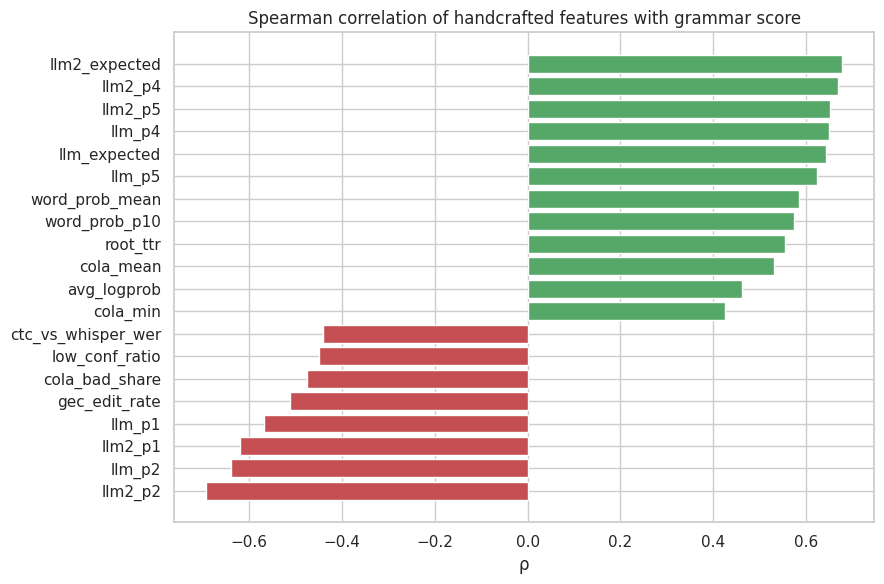

In [19]:
# Which handcrafted features move with the grammar score?  (Spearman ρ on scored training clips)
m = TR & (all_df.label > 0).values
rho = HAND[m].apply(lambda c: spearmanr(c, all_df.label[m], nan_policy="omit")[0]).dropna().sort_values()
top = pd.concat([rho.head(8), rho.tail(12)])
plt.figure(figsize=(9, 6))
plt.barh(top.index, top.values, color=["#c44e52" if v < 0 else "#55a868" for v in top.values])
plt.title("Spearman correlation of handcrafted features with grammar score"); plt.xlabel("ρ")
plt.tight_layout(); plt.show()

## 6. Deep embeddings (audio & text)
For each pretrained encoder we keep **every layer**: frame-level hidden states are pooled with **mean + standard deviation**
over time (audio) or a masked mean over tokens (text). Long clips are processed in chunks (20 s for WavLM, 30 s for the
Whisper encoder, which is its native window) and the frames are concatenated before pooling.
Which layer is most useful is decided later by cross-validation ("layer-wise probing").

**w2v-BERT 2.0** (Meta, 600M parameters, 4.5 M hours of unlabelled speech) adds a fourth, differently pre-trained view of the
audio. **Text-LLM embeddings** come from the rubric-judge pass of Section 5.1 (mean over the transcript tokens + the final
decision token, every layer).

**Audio LLM (Qwen2-Audio-7B-Instruct).** Speech LLMs give the best results in recent L2-assessment research
(Ma et al., 2025) and in the strongest public solutions of this competition. The model *listens* to the clip together with an
instruction ("assess the grammatical accuracy ..."), so its hidden states are task-conditioned. Per layer we keep the mean over
the audio-token positions and the final-token state. It is loaded in 4-bit (~5 GB) to fit a single T4, runs only on GPU, and
is skipped gracefully if it cannot be loaded.

In [20]:
from transformers import AutoModel, WhisperFeatureExtractor, WhisperModel as HFWhisper

def wavlm_embeddings(name, chunk_s=20):
    fe = AutoFeatureExtractor.from_pretrained(name)
    model = AutoModel.from_pretrained(name).to(DEVICE).eval()
    if GPU: model = model.half()
    out = []
    for p in tqdm(all_df.path, desc=name.split("/")[-1]):
        y = load_audio(p)
        if len(y) < SR: y = np.pad(y, (0, SR - len(y)))
        hs_all = []
        for s in range(0, len(y), chunk_s * SR):
            seg = y[s: s + chunk_s * SR]
            if len(seg) < SR // 2 and hs_all: break           # skip tiny tail chunks
            x = fe(seg, sampling_rate=SR, return_tensors="pt").input_values.to(DEVICE, DTYPE)
            with torch.no_grad():
                hs = model(x, output_hidden_states=True).hidden_states
            hs_all.append(torch.stack(hs)[:, 0].float())        # [layers, frames, dim]
        H = torch.cat(hs_all, 1)
        out.append(torch.cat([H.mean(1), H.std(1)], -1).cpu().numpy().astype(np.float16))
    del model; free()
    return np.stack(out)                                          # [N, layers, 2*dim]

def whisper_encoder_embeddings(name, chunk_s=30):
    fe = WhisperFeatureExtractor.from_pretrained(name)
    enc = HFWhisper.from_pretrained(name).get_encoder().to(DEVICE).eval()
    if GPU: enc = enc.half()
    out = []
    for p in tqdm(all_df.path, desc=name.split("/")[-1] + " encoder"):
        y = load_audio(p)
        hs_all = []
        for s in range(0, len(y), chunk_s * SR):
            seg = y[s: s + chunk_s * SR]
            if len(seg) < SR // 2 and hs_all: break
            feats = fe(seg, sampling_rate=SR, return_tensors="pt").input_features.to(DEVICE, DTYPE)
            n_frames = max(1, int(np.ceil(len(seg) / SR * 50)))    # 50 encoder frames per second; drop padding
            with torch.no_grad():
                hs = enc(feats, output_hidden_states=True).hidden_states
            hs_all.append(torch.stack(hs)[:, 0, :n_frames].float())
        H = torch.cat(hs_all, 1)
        out.append(torch.cat([H.mean(1), H.std(1)], -1).cpu().numpy().astype(np.float16))
    del enc; free()
    return np.stack(out)

def text_embeddings(name):
    tok = AutoTokenizer.from_pretrained(name)
    model = AutoModel.from_pretrained(name).to(DEVICE).eval()
    out = []
    for t in tqdm(all_df.text, desc=name):
        enc = tok(t or ".", return_tensors="pt", truncation=True, max_length=512).to(DEVICE)
        with torch.no_grad():
            hs = torch.stack(model(**enc, output_hidden_states=True).hidden_states)[:, 0].float()
        mask = enc.attention_mask[0].float()[None, :, None]
        out.append(((hs * mask).sum(1) / mask.sum(1)).cpu().numpy().astype(np.float16))
    del model; free()
    return np.stack(out)

AUDIO_LLM_PROMPT = ("Listen to this English learner's spoken answer and assess the grammatical accuracy "
                    "and sentence structure of their speech.")

def audio_llm_embeddings(name, chunk_s=30):
    # Hidden states of a speech LLM (Qwen2-Audio) conditioned on a grammar-assessment instruction.
    # Per layer: mean over the audio-token positions + the final token's state (which has "read" the whole
    # clip and the instruction). The model accepts ≤30 s of audio, so clips are processed in 30 s chunks.
    from transformers import AutoProcessor, Qwen2AudioForConditionalGeneration, BitsAndBytesConfig
    processor = AutoProcessor.from_pretrained(name)
    kw = dict(device_map="auto", torch_dtype=torch.float16)
    if GPU and CFG["audio_llm_4bit"]:          # 7B in 4-bit ≈ 5 GB → fits on one T4
        kw["quantization_config"] = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4",
                                                       bnb_4bit_compute_dtype=torch.float16)
    if not GPU:
        kw = dict(torch_dtype=torch.float32)
    model = Qwen2AudioForConditionalGeneration.from_pretrained(name, **kw).eval()
    dev = next(model.parameters()).device
    conv = [{"role": "user", "content": [{"type": "audio", "audio_url": "clip.wav"},
                                         {"type": "text", "text": AUDIO_LLM_PROMPT}]}]
    text = processor.apply_chat_template(conv, add_generation_prompt=True, tokenize=False)
    audio_id = processor.tokenizer.convert_tokens_to_ids("<|AUDIO|>")

    def encode(seg):
        # the audio keyword was renamed across transformers versions (audios → audio)
        for key in ("audio", "audios"):
            try:
                inp = processor(text=text, **{key: [seg]}, sampling_rate=SR, return_tensors="pt", padding=True)
                if "input_features" in inp:
                    return inp
            except (TypeError, ValueError):
                pass
        raise RuntimeError("processor did not return audio features")

    out = []
    for p in tqdm(all_df.path, desc=name.split("/")[-1]):
        y = load_audio(p)
        aud, last = [], []
        for s in range(0, len(y), chunk_s * SR):
            seg = y[s: s + chunk_s * SR]
            if len(seg) < 2 * SR and aud: break               # skip tiny tail chunks
            inp = encode(seg).to(dev)
            inp["input_features"] = inp["input_features"].to(DTYPE)
            with torch.no_grad():
                hs = torch.stack(model(**inp, output_hidden_states=True).hidden_states)[:, 0].float()
            mask = (inp["input_ids"][0] == audio_id)
            aud.append(hs[:, mask] if mask.any() else hs)       # [layers, audio_tokens, dim]
            last.append(hs[:, -1])                              # [layers, dim]
        A = torch.cat(aud, 1).mean(1)
        out.append(torch.cat([A, torch.stack(last).mean(0)], -1).cpu().numpy().astype(np.float16))
    del model; free()
    return np.stack(out)                                         # [N, layers, 2*dim]

def w2vbert_embeddings(name, chunk_s=20):
    # w2v-BERT 2.0 (600M, pre-trained on 4.5M hours): mean + std pooling of every layer
    from transformers import Wav2Vec2BertModel
    fe = AutoFeatureExtractor.from_pretrained(name)
    model = Wav2Vec2BertModel.from_pretrained(name).to(DEVICE).eval()
    if GPU: model = model.half()
    out = []
    for p in tqdm(all_df.path, desc=name.split("/")[-1]):
        y = load_audio(p)
        hs_all = []
        for s in range(0, len(y), chunk_s * SR):
            seg = y[s: s + chunk_s * SR]
            if len(seg) < SR // 2 and hs_all: break
            inp = fe(seg, sampling_rate=SR, return_tensors="pt")
            with torch.no_grad():
                hs = model(inp.input_features.to(DEVICE, DTYPE), output_hidden_states=True).hidden_states
            hs_all.append(torch.stack(hs)[:, 0].float())
        H = torch.cat(hs_all, 1)
        out.append(torch.cat([H.mean(1), H.std(1)], -1).cpu().numpy().astype(np.float16))
    del model; free()
    return np.stack(out)

EMB = {
    "wavlm":   cached("emb_wavlm",   lambda: wavlm_embeddings(CFG["wavlm"])),
    "whisper": cached("emb_whisper", lambda: whisper_encoder_embeddings(CFG["whisper_enc"])),
    "text":    cached("emb_text",    lambda: text_embeddings(CFG["text_enc"])),
}
W2VBERT_EMB = safe("w2v-BERT", lambda: cached("emb_w2vbert", lambda: run_and_drop(w2vbert_embeddings, CFG["w2vbert"])), None)
for k, E in [("w2vbert", W2VBERT_EMB), ("textllm", TEXT_LLM_EMB), ("judgellm", JUDGE2_EMB)]:
    if E is not None:                                  # optional branches that could not be computed are skipped
        EMB[k] = E
if CFG["use_audio_llm"] or feature_path("emb_audiollm"):
    try:
        EMB["audiollm"] = cached("emb_audiollm", lambda: run_and_drop(audio_llm_embeddings, CFG["audio_llm"]))
    except Exception as e:      # e.g. out of memory / old transformers -> continue without this branch
        print("Audio-LLM branch skipped:", repr(e)[:300]); free()
for k, v in EMB.items():
    print(f"{k:8s} → {v.shape}  (clips, layers, features)")

preprocessor_config.json:   0%|          | 0.00/214 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/2.22k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 1.26GB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.26GB            

...

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/876 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/230 [00:00<?, ?B/s]

Qwen2-Audio-7B-Instruct:   0%|          | 0/985 [00:00<?, ?it/s]

  [emb_audiollm] computed in 36.4 min
wavlm    → (985, 25, 2048)  (clips, layers, features)
whisper  → (985, 33, 2560)  (clips, layers, features)
text     → (985, 25, 1024)  (clips, layers, features)
w2vbert  → (985, 25, 2048)  (clips, layers, features)
textllm  → (985, 29, 7168)  (clips, layers, features)
judgellm → (985, 41, 10240)  (clips, layers, features)
audiollm → (985, 33, 8192)  (clips, layers, features)


## 7. Cross-validation set-up and models
* **Training rows:** scored clips only (label ≥ 1). Zero-score clips (label 0) are handled in Section 9.
* **Folds:** `StratifiedGroupKFold` with 5 folds, stratified on the rounded score and grouped by speaker cluster,
  repeated with 3 different seeds (15 fits per model). Out-of-fold (OOF) predictions are averaged over the repeats;
  test predictions are averaged over all 15 fitted models.
* **Models:** with ~730 samples and 1 000–5 000 features, strongly regularised models are the right choice:
  `RidgeCV` (α chosen internally on each training fold), RBF-`SVR`, an **ordinal head** (multinomial logistic regression
  over the half-point levels on 256 PCA components; prediction = expected level) and `HistGradientBoosting` for the
  handcrafted features.
  All scaling / imputation is fitted inside each fold, so there is no leakage.

In [21]:
FIT = TR & (all_df.label > 0).values           # rows used to train the regressors
y = all_df.label[FIT].values.astype(float)
groups = all_df.speaker[FIT].values
strata = np.clip(np.round(y), 1, 5).astype(int)

FOLDS = {s: list(StratifiedGroupKFold(CFG["n_folds"], shuffle=True, random_state=s)
                 .split(np.zeros(len(y)), strata, groups)) for s in SEEDS}

def metrics(y_true, y_pred):
    return dict(RMSE=np.sqrt(mean_squared_error(y_true, y_pred)), MAE=mean_absolute_error(y_true, y_pred),
                Pearson=pearsonr(y_true, y_pred)[0], Spearman=spearmanr(y_true, y_pred)[0],
                within_0_5=np.mean(np.abs(y_true - y_pred) <= 0.5))

class OrdinalExpectation(BaseEstimator, RegressorMixin):
    # Classifier over the half-point score levels; the prediction is the probability-weighted (expected) level
    def __init__(self, C=0.05, n_components=256):
        self.C, self.n_components = C, n_components

    def fit(self, X, y):
        # classes are half-points stored as integers (score × 2); 1.0 has a single clip → merged into 1.5
        levels = np.clip(np.round(np.asarray(y) * 2), 3, 10).astype(int)
        k = min(self.n_components, X.shape[0] - 1, X.shape[1])
        self.pipe_ = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(),
                                   PCA(k, random_state=SEED), LogisticRegression(C=self.C, max_iter=3000))
        self.pipe_.fit(X, levels)
        return self

    def predict(self, X):
        return self.pipe_.predict_proba(X) @ (self.pipe_.classes_ / 2)

class KNNHead(BaseEstimator, RegressorMixin):
    # Distance-weighted cosine k-nearest neighbours on the first PCA components: a non-parametric view for the stack
    def __init__(self, n_neighbors=20, n_components=64):
        self.n_neighbors, self.n_components = n_neighbors, n_components

    def fit(self, X, y):
        k = min(self.n_components, X.shape[0] - 1, X.shape[1])
        self.pipe_ = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), PCA(k, random_state=SEED),
                                   KNeighborsRegressor(n_neighbors=min(self.n_neighbors, X.shape[0] - 1),
                                                       weights="distance", metric="cosine"))
        self.pipe_.fit(X, y)
        return self

    def predict(self, X):
        return self.pipe_.predict(X)

ALPHAS = np.logspace(-1, 5, 25)
MODELS = {
    "ordinal": lambda: OrdinalExpectation(),
    "knn":     lambda: KNNHead(),
    "ridge": lambda: make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), RidgeCV(alphas=ALPHAS)),
    "svr":   lambda: make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), SVR(C=10, epsilon=0.1)),
    "hgb":   lambda: HistGradientBoostingRegressor(max_depth=3, learning_rate=0.04, max_iter=400,
                                                   l2_regularization=1.0, min_samples_leaf=15, random_state=SEED),
}

def run_cv(X, Xte, model, seeds=SEEDS):
    # Returns OOF predictions (averaged over seeds) and test predictions (averaged over all fold models)
    oof = np.zeros((len(seeds), len(X))); te = []
    for r, s in enumerate(seeds):
        for tr, va in FOLDS[s]:
            m = MODELS[model]().fit(X[tr], y[tr])
            oof[r, va] = m.predict(X[va])
            te.append(m.predict(Xte))
    return oof.mean(0), np.mean(te, 0)

### 7.1 Layer-wise probing
Different layers of a speech / text encoder encode different information (acoustics in early layers, phonetics and
lexical/syntactic content in middle-to-deep layers). We probe every layer with a quick Ridge model on one CV seed and keep
the best layer for each encoder. Around that layer we also try the **average of ±1 and ±2 neighbouring layers**, which is
often more stable than a single layer, and keep whichever is best. *(Selecting layers on the same folds introduces a small
optimistic bias; it is standard practice and the 3-seed evaluation below dilutes it.)*

  [layer_probe_7] computed in 9.9 min


,best_layer,window,rmse_single,rmse_used
wavlm,19,±0,0.591141,0.591141
whisper,32,±2,0.577699,0.577589
text,19,±1,0.616907,0.615589
w2vbert,12,±0,0.632171,0.632171
textllm,19,±1,0.597585,0.595551
judgellm,29,±1,0.589353,0.588665
audiollm,13,±0,0.576653,0.576653


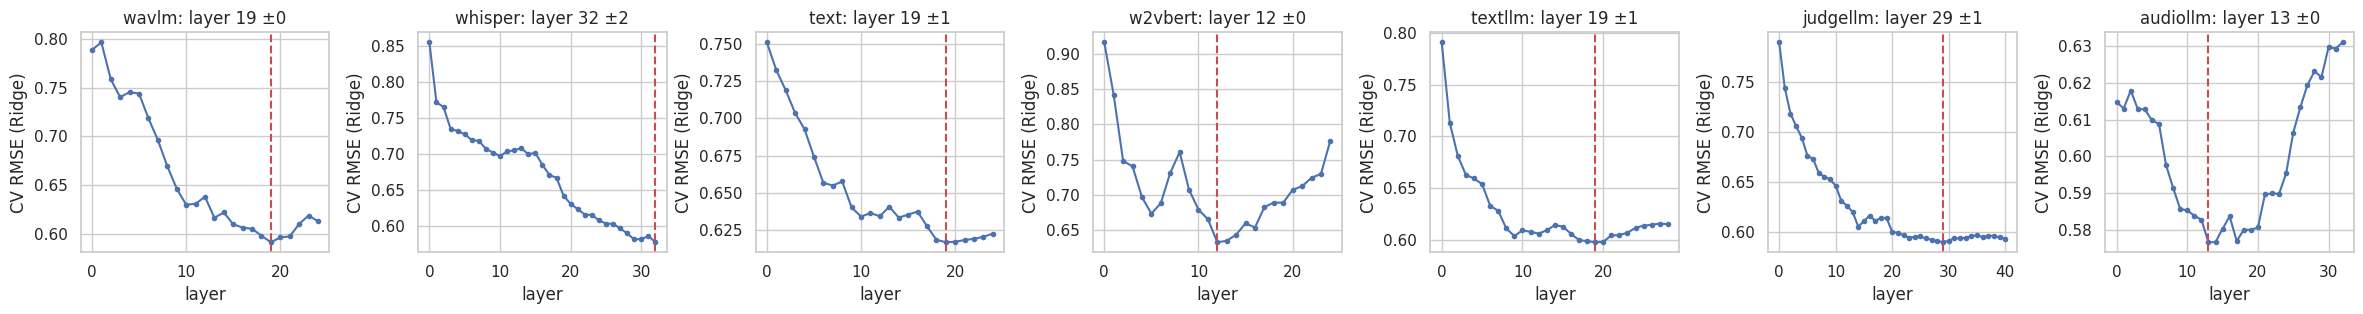

In [22]:
def layer_view(E, layer, width):
    # Average of the layers layer-width … layer+width (width 0 = the single layer)
    lo, hi = max(0, layer - width), min(E.shape[1], layer + width + 1)
    return E[:, lo:hi].astype(np.float32).mean(1)

def probe(X):
    oof, _ = run_cv(X[FIT], X[TE][:1], "ridge", seeds=SEEDS[:1])
    return np.sqrt(mean_squared_error(y, oof))

def probe_encoder(E):
    single = np.array([probe(E[:, l].astype(np.float32)) for l in range(E.shape[1])])
    best = int(np.argmin(single))
    windows = {w: probe(layer_view(E, best, w)) for w in (1, 2)}
    return single, best, windows

PROBE = cached(f"layer_probe_{len(EMB)}", lambda: {k: probe_encoder(E) for k, E in EMB.items()}, shared=False)
LAYER_SPEC = {}                                       # encoder → (best layer, window half-width)
for k, (single, best, windows) in PROBE.items():
    w = min(windows, key=windows.get)
    LAYER_SPEC[k] = (best, w if windows[w] < single[best] else 0)
display(pd.DataFrame({k: dict(best_layer=b, window=f"±{w}", rmse_single=PROBE[k][0][b],
                              rmse_used=min([PROBE[k][0][b]] + list(PROBE[k][2].values())))
                      for k, (b, w) in LAYER_SPEC.items()}).T)

fig, ax = plt.subplots(1, len(PROBE), figsize=(3.4 * len(PROBE), 3.3))
for a, (k, (single, best, windows)) in zip(ax, PROBE.items()):
    a.plot(single, marker="o", ms=3); a.axvline(best, color="r", ls="--")
    a.set(title=f"{k}: layer {best} ±{LAYER_SPEC[k][1]}", xlabel="layer", ylabel="CV RMSE (Ridge)")
plt.tight_layout(); plt.show()

## 8. Base models and stacking
Each embedding view gets four regressors (Ridge, SVR with a `C` tuned for that view, ordinal head, KNN); the handcrafted
view gets Ridge, gradient boosting and an ordinal head. Their out-of-fold predictions are combined by one of two stackers,
whichever has the lower **nested** CV RMSE (the stacker is itself cross-validated on the same speaker-grouped folds):
* **non-negative linear stacking**: a linear regression with weights ≥ 0;
* **ensemble selection** (Caruana et al., 2004): greedily add (with replacement) the model that most lowers RMSE,
  then rescale linearly. With many correlated models this is often more robust than fitting all weights at once.

In [23]:
BLOCKS = {"hand": HAND.values.astype(np.float32)}
BLOCKS.update({k: layer_view(E, *LAYER_SPEC[k]) for k, E in EMB.items()})   # best layer / layer window per encoder
BASE = [("hand", "ridge"), ("hand", "hgb"), ("hand", "ordinal")] + \
       [(k, m) for k in EMB for m in ("svr", "ridge", "ordinal", "knn")]
print("base models:", [f"{b}_{m}" for b, m in BASE])

def svr_factory(C):
    return lambda: make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), SVR(C=C, epsilon=0.1))

def tune_svr_C(X, grid=(1, 3, 10, 30)):
    # One-seed CV over C (like the layer probe); the 3-seed evaluation below uses the chosen value
    scores = {}
    for C in grid:
        MODELS["svr_probe"] = svr_factory(C)
        oof, _ = run_cv(X[FIT], X[TE][:1], "svr_probe", seeds=SEEDS[:1])
        scores[C] = np.sqrt(mean_squared_error(y, oof))
    return min(scores, key=scores.get)

SVR_C = cached(f"svr_C_{len(BLOCKS)}", lambda: {k: tune_svr_C(X) for k, X in BLOCKS.items() if k != "hand"},
               shared=False)
print("SVR C per view:", SVR_C)
for blk, C in SVR_C.items():
    MODELS[f"svr@{blk}"] = svr_factory(C)
model_key = lambda blk, mdl: f"svr@{blk}" if mdl == "svr" else mdl

def fit_base():
    oof, te = {}, {}
    for blk, mdl in tqdm(BASE, desc="base models"):
        oof[f"{blk}_{mdl}"], te[f"{blk}_{mdl}"] = run_cv(BLOCKS[blk][FIT], BLOCKS[blk][TE], model_key(blk, mdl))
    return pd.DataFrame(oof), pd.DataFrame(te)

OOF, TEST_PRED = cached(f"base_models_{len(BASE)}", fit_base, shared=False)

class EnsembleSelection:
    # Caruana et al. (2004): greedy forward selection with replacement, then a linear rescale of the average
    def __init__(self, iters=100):
        self.iters = iters

    def fit(self, P, t):
        counts, cur = np.zeros(P.shape[1]), np.zeros(len(t))
        for it in range(1, self.iters + 1):
            j = int(np.argmin([np.mean(((cur * (it - 1) + P[:, k]) / it - t) ** 2) for k in range(P.shape[1])]))
            counts[j] += 1
            cur = (cur * (it - 1) + P[:, j]) / it
        w = counts / counts.sum()
        lin = LinearRegression().fit((P @ w)[:, None], t)
        self.coef_, self.intercept_ = w * lin.coef_[0], lin.intercept_     # same interface as LinearRegression
        return self

    def predict(self, P):
        return P @ self.coef_ + self.intercept_

STACKERS = {"non-negative linear": lambda: LinearRegression(positive=True),
            "ensemble selection": lambda: EnsembleSelection()}

def stack_cv(cols, make=None):
    # Honest (nested) CV of a stacker on top of the out-of-fold predictions
    make = make or STACKERS[STACKER]
    P = OOF[cols].values; pred = np.zeros((len(SEEDS), len(y)))
    for r, s in enumerate(SEEDS):
        for tr, va in FOLDS[s]:
            pred[r, va] = make().fit(P[tr], y[tr]).predict(P[va])
    return np.clip(pred.mean(0), 0, 5)

ALL = list(OOF.columns)
stacker_cv = {name: stack_cv(ALL, make) for name, make in STACKERS.items()}
STACKER = min(stacker_cv, key=lambda k: np.sqrt(mean_squared_error(y, stacker_cv[k])))
print("stacker CV RMSE:", {k: round(np.sqrt(mean_squared_error(y, v)), 4) for k, v in stacker_cv.items()},
      "→ chosen:", STACKER)
stacker = STACKERS[STACKER]().fit(OOF[ALL].values, y)
oof_stack = stacker_cv[STACKER]

res = pd.DataFrame({c: metrics(y, OOF[c].clip(0, 5)) for c in ALL}).T
res.loc["STACK (all)"] = metrics(y, oof_stack)
res.round(4)

base models: ['hand_ridge', 'hand_hgb', 'hand_ordinal', 'wavlm_svr', 'wavlm_ridge', 'wavlm_ordinal', 'wavlm_knn', 'whisper_svr', 'whisper_ridge', 'whisper_ordinal', 'whisper_knn', 'text_svr', 'text_ridge', 'text_ordinal', 'text_knn', 'w2vbert_svr', 'w2vbert_ridge', 'w2vbert_ordinal', 'w2vbert_knn', 'textllm_svr', 'textllm_ridge', 'textllm_ordinal', 'textllm_knn', 'judgellm_svr', 'judgellm_ridge', 'judgellm_ordinal', 'judgellm_knn', 'audiollm_svr', 'audiollm_ridge', 'audiollm_ordinal', 'audiollm_knn']
  [svr_C_8] computed in 2.8 min
SVR C per view: {'wavlm': 10, 'whisper': 10, 'text': 1, 'w2vbert': 10, 'textllm': 10, 'judgellm': 10, 'audiollm': 10}


base models:   0%|          | 0/31 [00:00<?, ?it/s]

  [base_models_31] computed in 22.5 min
stacker CV RMSE: {'non-negative linear': np.float64(0.5108), 'ensemble selection': np.float64(0.5129)} → chosen: non-negative linear


,RMSE,MAE,Pearson,Spearman,within_0_5
hand_ridge,0.6712,0.5278,0.7495,0.7526,0.5642
hand_hgb,0.6424,0.4970,0.7738,0.7625,0.5874
hand_ordinal,0.6511,0.5163,0.7679,0.7554,0.5697
wavlm_svr,0.5784,0.4505,0.8259,0.8139,0.6216
wavlm_ridge,0.5848,0.4516,0.8172,0.8088,0.6216
wavlm_ordinal,0.6242,0.4694,0.7913,0.7736,0.6120
wavlm_knn,0.6581,0.4991,0.7615,0.7293,0.6011
whisper_svr,0.5741,0.4493,0.8270,0.8124,0.6257
whisper_ridge,0.5751,0.4411,0.8238,0.8129,0.6366
whisper_ordinal,0.5955,0.4489,0.8117,0.7913,0.6352


,RMSE,MAE,Pearson,Spearman,within_0_5
handcrafted + judges + GEC,0.6293,0.4893,0.7840,0.7740,0.6093
text views (RoBERTa + LLMs),0.5713,0.4498,0.8261,0.8212,0.6516
text + handcrafted (ASR-based),0.5637,0.4403,0.8312,0.8249,0.6585
audio views only,0.5413,0.4100,0.8456,0.8311,0.6694
all views except text LLM,0.5105,0.3889,0.8640,0.8534,0.6858
all views except w2v-BERT,0.5112,0.3900,0.8636,0.8531,0.6831
all views except audio LLM,0.5132,0.3921,0.8625,0.8518,0.6831
all views except Qwen3 judge,0.5128,0.3890,0.8627,0.8522,0.6926
"all views, no ordinal heads",0.5162,0.3945,0.8608,0.8532,0.6721
"all views, no KNN heads",0.5077,0.3865,0.8656,0.8551,0.6913


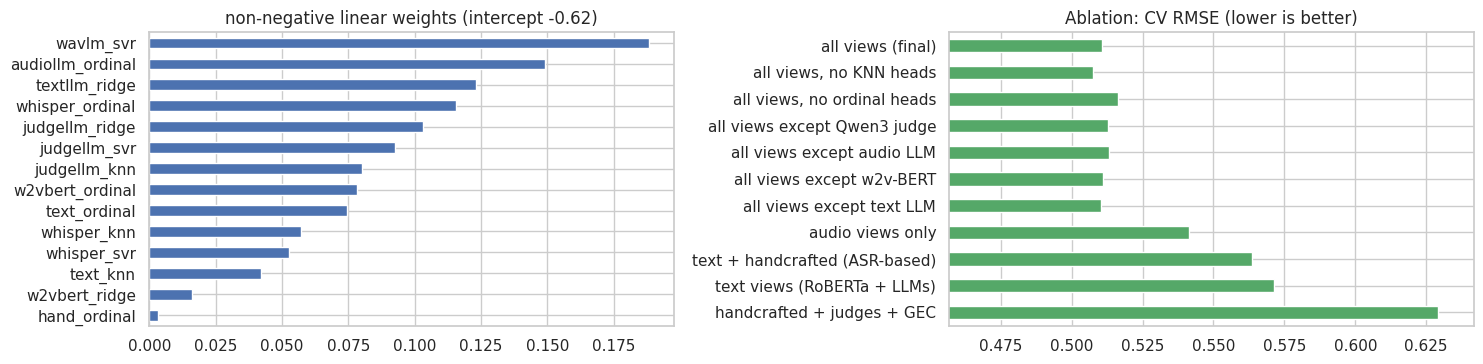

In [24]:
# Ablation: which views matter?
abl = {
    "handcrafted + judges + GEC":     [c for c in ALL if c.startswith("hand")],
    "text views (RoBERTa + LLMs)":    [c for c in ALL if c.startswith(("text", "judgellm"))],
    "text + handcrafted (ASR-based)": [c for c in ALL if c.startswith(("text", "judgellm", "hand"))],
    "audio views only":               [c for c in ALL if c.startswith(("wavlm", "whisper", "w2vbert", "audiollm"))],
    "all views except text LLM":      [c for c in ALL if not c.startswith("textllm")],
    "all views except w2v-BERT":      [c for c in ALL if not c.startswith("w2vbert")],
    "all views except audio LLM":     [c for c in ALL if not c.startswith("audiollm")],
    "all views except Qwen3 judge":   [c for c in ALL if not c.startswith("judgellm")],
    "all views, no ordinal heads":    [c for c in ALL if not c.endswith("_ordinal")],
    "all views, no KNN heads":        [c for c in ALL if not c.endswith("_knn")],
    "all views (final)":              ALL,
}
abl = {k: v for k, v in abl.items() if v}
ablation = pd.DataFrame({k: metrics(y, stack_cv(v)) for k, v in abl.items()}).T
display(ablation.round(4))

w = pd.Series(stacker.coef_, index=ALL)
fig, ax = plt.subplots(1, 2, figsize=(15, 3.8))
w = w[w.abs() > 1e-6]                              # show only the models the stacker actually uses
w.sort_values().plot.barh(ax=ax[0], color="#4c72b0")
ax[0].set(title=f"{STACKER} weights (intercept {stacker.intercept_:.2f})")
ablation["RMSE"].plot.barh(ax=ax[1], color="#55a868"); ax[1].set(title="Ablation: CV RMSE (lower is better)")
ax[1].set_xlim(ablation.RMSE.min() * 0.9, ablation.RMSE.max() * 1.02)
plt.tight_layout(); plt.show()

### 8.1 Score-aware calibration (range stretch)
Regression models trained with squared error **shrink predictions towards the mean**: true 5s tend to be predicted around
4.5 and true 2s around 2.6. Top competitors countered this with a "range stretch". Because our stacker is a linear
regression it already learns a global scale, so a fixed stretch factor is *not* assumed to help; instead three calibrators
are compared **with cross-validation on the honest out-of-fold stack predictions**, and one is kept only if it clearly
lowers CV RMSE:

| Calibrator | What it does |
|---|---|
| `none` | keep the stacked prediction |
| `stretch` | linear map `a + b*p` fitted on out-of-fold predictions (b > 1 = stretch away from the mean) |
| `isotonic` | monotone, piece-wise map; can stretch the extremes (1-2 and 4.5-5) differently from the middle |

chosen calibrator: none | linear stretch factor b = 1.008


,RMSE,MAE,Pearson,Spearman,within_0_5
none,0.5108,0.3887,0.8638,0.8534,0.6872
stretch,0.5116,0.3885,0.8633,0.8527,0.6913
isotonic,0.5137,0.3918,0.8622,0.8423,0.6844


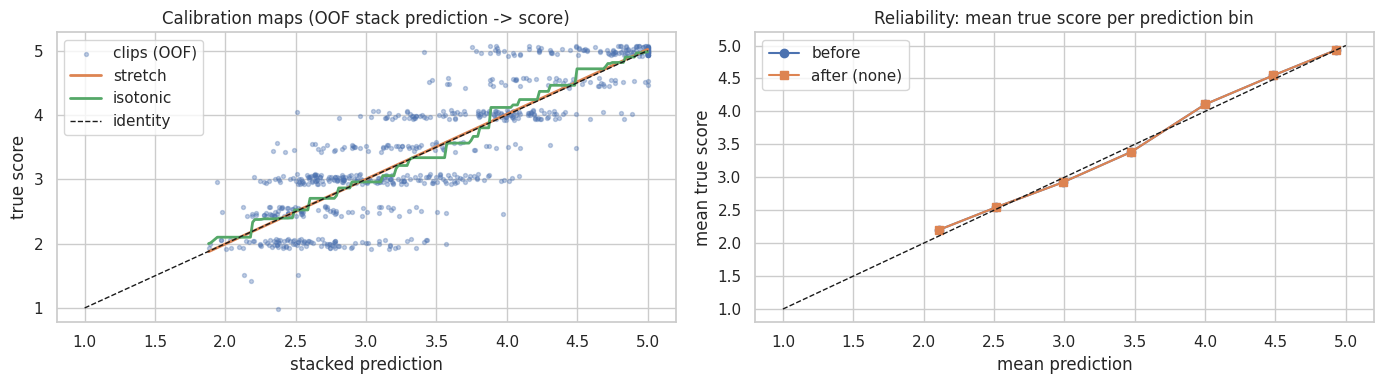

In [25]:
from sklearn.isotonic import IsotonicRegression

def fit_calibrator(kind, p, t):
    if kind == "stretch":
        lr = LinearRegression().fit(p[:, None], t)
        return lambda x: lr.predict(np.asarray(x)[:, None])
    if kind == "isotonic":
        iso = IsotonicRegression(y_min=1, y_max=5, out_of_bounds="clip").fit(p, t)
        return iso.predict
    return lambda x: np.asarray(x)

def calib_cv(kind):
    # Calibrator fitted on the training folds of the OOF stack predictions, applied to the held-out fold
    out = np.zeros((len(SEEDS), len(y)))
    for r, s in enumerate(SEEDS):
        for tr, va in FOLDS[s]:
            out[r, va] = fit_calibrator(kind, oof_stack[tr], y[tr])(oof_stack[va])
    return np.clip(out.mean(0), 1, 5)

CAL_OOF = {k: calib_cv(k) for k in ["none", "stretch", "isotonic"]}
calib_table = pd.DataFrame({k: metrics(y, v) for k, v in CAL_OOF.items()}).T
best = calib_table.RMSE.idxmin()
CALIB = best if calib_table.RMSE[best] < calib_table.RMSE["none"] - 0.002 else "none"   # must clearly help
calibrator = fit_calibrator(CALIB, oof_stack, y)
finalize = lambda p: np.clip(calibrator(np.asarray(p, dtype=float)), 1, 5)            # scored clips live on 1-5
oof_final = CAL_OOF[CALIB]
lin = LinearRegression().fit(oof_stack[:, None], y)
print(f"chosen calibrator: {CALIB} | linear stretch factor b = {lin.coef_[0]:.3f}")
display(calib_table.round(4))

grid = np.linspace(oof_stack.min(), oof_stack.max(), 200)
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].scatter(oof_stack, y + np.random.uniform(-0.08, 0.08, len(y)), s=8, alpha=0.35, label="clips (OOF)")
for k, c in [("stretch", "#dd8452"), ("isotonic", "#55a868")]:
    ax[0].plot(grid, fit_calibrator(k, oof_stack, y)(grid), color=c, lw=2, label=k)
ax[0].plot([1, 5], [1, 5], "k--", lw=1, label="identity")
ax[0].set(title="Calibration maps (OOF stack prediction -> score)", xlabel="stacked prediction", ylabel="true score")
ax[0].legend()
bins = pd.cut(oof_stack, np.arange(0.75, 5.5, 0.5))
rel = pd.DataFrame({"pred": oof_stack, "cal": oof_final, "true": y}).groupby(bins, observed=True).mean()
ax[1].plot(rel.pred, rel.true, "o-", label="before"); ax[1].plot(rel.cal, rel.true, "s-", label=f"after ({CALIB})")
ax[1].plot([1, 5], [1, 5], "k--", lw=1)
ax[1].set(title="Reliability: mean true score per prediction bin", xlabel="mean prediction", ylabel="mean true score")
ax[1].legend(); plt.tight_layout(); plt.show()

## 9. Zero-score clip detector (label 0)
The 37 zero-score clips are not "very bad grammar". The plot below shows they contain about as many recognised words as
scored clips, so they are **not** silent; instead they behave like a separate recording batch (another public solution of
this competition reports the same). A small logistic regression on interpretable recording / ASR signals (Whisper
no-speech probability and confidence, speech fraction, spectral flatness, speaking rate, word count) recognises this batch.
Only very confident detections (p > 0.8) are mapped to 0, because a false positive on a real speaker would be very costly
for RMSE.

CV AUC = 1.000 | CV flagged 37 (true zeros 37, correct 37) | test clips flagged as zero-score: 0


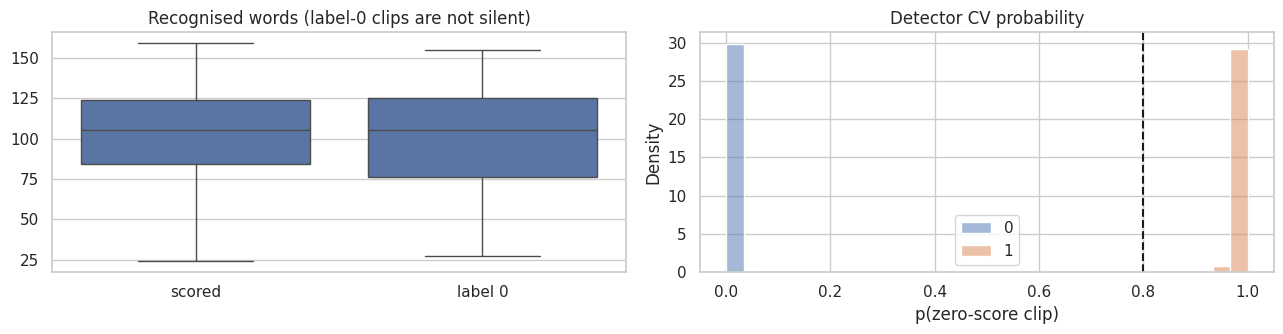

In [26]:
ZERO_FEATS = [c for c in ["n_words", "no_speech_prob", "avg_logprob", "word_prob_mean",
                           "speech_fraction", "flatness_mean", "words_per_sec"] if c in HAND]
Xz = HAND[ZERO_FEATS].values
is_zero = (all_df.label[TR] == 0).astype(int).values
detector = lambda: make_pipeline(SimpleImputer(strategy="median"), StandardScaler(),
                                 LogisticRegression(class_weight="balanced", C=0.5, max_iter=1000))
ZERO_T = 0.8
cv_zero = cross_val_predict(detector(), Xz[TR], is_zero,
                             cv=StratifiedKFold(5, shuffle=True, random_state=SEED), method="predict_proba")[:, 1]
zero_model = detector().fit(Xz[TR], is_zero)
p_zero_test = zero_model.predict_proba(Xz[TE])[:, 1]
print(f"CV AUC = {roc_auc_score(is_zero, cv_zero):.3f} | CV flagged {(cv_zero > ZERO_T).sum()} "
      f"(true zeros {is_zero.sum()}, correct {((cv_zero > ZERO_T) & (is_zero == 1)).sum()}) | "
      f"test clips flagged as zero-score: {(p_zero_test > ZERO_T).sum()}")

fig, ax = plt.subplots(1, 2, figsize=(13, 3.5))
sns.boxplot(x=is_zero, y=HAND.loc[TR, "n_words"].values, ax=ax[0]); ax[0].set(title="Recognised words (label-0 clips are not silent)", xticklabels=["scored", "label 0"])
sns.histplot(x=cv_zero, hue=is_zero, bins=30, ax=ax[1], stat="density", common_norm=False)
ax[1].axvline(ZERO_T, color="k", ls="--"); ax[1].set(title="Detector CV probability", xlabel="p(zero-score clip)")
plt.tight_layout(); plt.show()

### 9.1 Speaker prior for known speakers
Section 3 showed that clips of the same speaker get almost the same score. Cross-validation keeps speakers apart, but
in the real test set about 1 in 9 clips comes from a speaker who **also appears in the training data**. For those clips we
blend the model prediction with the mean score of that speaker's training clips:

`final = (1 − w) · model + w · speaker_mean`

The weight `w` is estimated honestly on training clips of repeated speakers: each clip's out-of-fold model prediction
(the model never saw that speaker) is blended with the mean of the *other* clips of the same speaker.

training clips with a repeated speaker: 440 | best weight w = 0.45 | RMSE on them: 0.4943 → 0.4204
test clips with a known speaker: 25 of 216


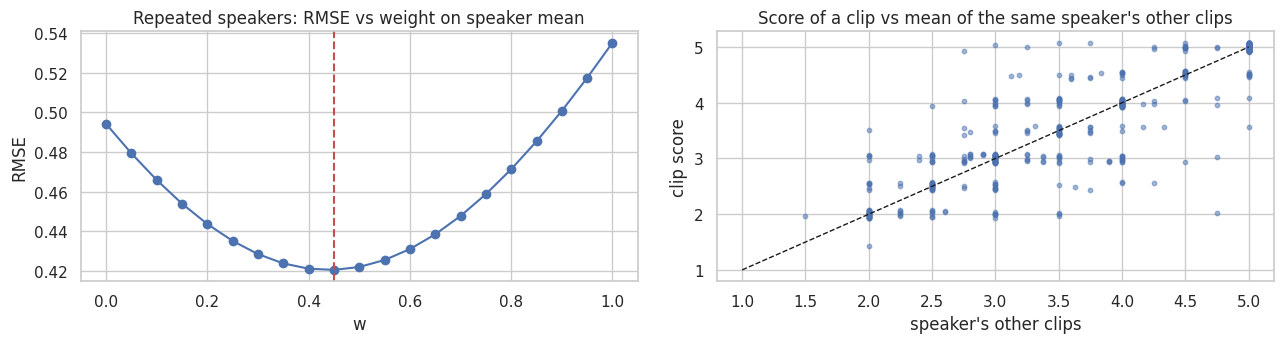

In [27]:
spk_fit = all_df.speaker.values[FIT]
other_mean = np.full(len(y), np.nan)                 # leave-one-out speaker mean for every scored training clip
for sp in np.unique(spk_fit):
    idx = np.where(spk_fit == sp)[0]
    if len(idx) > 1:
        other_mean[idx] = (y[idx].sum() - y[idx]) / (len(idx) - 1)
known = ~np.isnan(other_mean)

W_GRID = np.linspace(0, 1, 21)
if known.sum() >= 10:
    spk_curve = np.array([np.sqrt(mean_squared_error(y[known], (1 - w) * oof_final[known] + w * other_mean[known]))
                          for w in W_GRID])
else:                                                # too few repeated speakers to estimate a weight: no prior
    spk_curve = np.full(len(W_GRID), np.nan)
SPK_W = float(W_GRID[np.nanargmin(spk_curve)]) if known.sum() >= 10 else 0.0

spk_train_mean = pd.Series(y).groupby(spk_fit).mean()
test_spk_mean = pd.Series(all_df.speaker.values[TE]).map(spk_train_mean).values
test_known = ~np.isnan(test_spk_mean)
print(f"training clips with a repeated speaker: {known.sum()} | best weight w = {SPK_W:.2f} | "
      f"RMSE on them: {spk_curve[0]:.4f} → {spk_curve.min():.4f}")
print(f"test clips with a known speaker: {test_known.sum()} of {TE.sum()}")

fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
ax[0].plot(W_GRID, spk_curve, marker="o"); ax[0].axvline(SPK_W, color="r", ls="--")
ax[0].set(title="Repeated speakers: RMSE vs weight on speaker mean", xlabel="w", ylabel="RMSE")
ax[1].scatter(other_mean[known], y[known] + np.random.uniform(-0.08, 0.08, known.sum()), s=10, alpha=0.5)
ax[1].plot([1, 5], [1, 5], "k--", lw=1)
ax[1].set(title="Score of a clip vs mean of the same speaker's other clips", xlabel="speaker's other clips", ylabel="clip score")
plt.tight_layout(); plt.show()

## 10. Evaluation
### 10.1 Training RMSE (compulsory) and cross-validated metrics
* **Training RMSE:** every base model is refit on *all* scored training clips and predicts those same clips; predictions
  are stacked with the final weights and calibrated. Zero-score clips get 0 if the detector (fit on all training data) flags them.
  This is an *in-sample* number and is optimistic by construction.
* **Cross-validation:** the honest estimate of performance on unseen speakers.

In [28]:
def fit_full_train_predictions():
    P = np.column_stack([MODELS[model_key(b, m)]().fit(BLOCKS[b][FIT], y).predict(BLOCKS[b][FIT]) for b, m in BASE])
    return stacker.predict(P)

train_pred_fit = finalize(cached(f"train_insample_{len(BASE)}", fit_full_train_predictions, shared=False))

# Full 769-clip training set: regressor on scored clips, detector decides zero-score clips
y_all = all_df.label[TR].values.astype(float)
fit_in_tr = FIT[TR]

def assemble(reg_pred_for_scored, p_zero):
    out = np.full(len(y_all), np.nan)
    out[fit_in_tr] = reg_pred_for_scored
    # clips that are actually label 0 get no regressor prediction: use the median score unless flagged
    out[~fit_in_tr] = np.median(y)
    out[p_zero > ZERO_T] = 0.0
    return out

p_zero_train_in = zero_model.predict_proba(Xz[TR])[:, 1]
train_full_in = assemble(train_pred_fit, p_zero_train_in)
train_full_cv = assemble(oof_final, cv_zero)

summary = pd.DataFrame({
    "TRAIN (in-sample), 732 scored clips": metrics(y, train_pred_fit),
    "TRAIN (in-sample), all 769 clips":    metrics(y_all, train_full_in),
    "CV (out-of-fold), 732 scored clips":  metrics(y, oof_final),
    "CV (out-of-fold), all 769 clips":     metrics(y_all, train_full_cv),
    "CV scored clips, before calibration": metrics(y, oof_stack),
    "Baseline: predict mean (CV)":         metrics(y, np.full_like(y, y.mean())),
}).T
TRAIN_RMSE = summary.loc["TRAIN (in-sample), all 769 clips", "RMSE"]
CV_ALL = summary.loc["CV (out-of-fold), all 769 clips"]
print(f"★ TRAINING RMSE = {TRAIN_RMSE:.4f}   |   ★ CV RMSE = {CV_ALL.RMSE:.4f}, CV Pearson = {CV_ALL.Pearson:.4f}")
summary.round(4)

  [train_insample_31] computed in 2.1 min
★ TRAINING RMSE = 0.1223   |   ★ CV RMSE = 0.4983, CV Pearson = 0.9155


,RMSE,MAE,Pearson,Spearman,within_0_5
"TRAIN (in-sample), 732 scored clips",0.1253,0.0953,0.9941,0.9870,1.0000
"TRAIN (in-sample), all 769 clips",0.1223,0.0907,0.9959,0.9888,1.0000
"CV (out-of-fold), 732 scored clips",0.5108,0.3887,0.8638,0.8534,0.6872
"CV (out-of-fold), all 769 clips",0.4983,0.3700,0.9155,0.8738,0.7022
"CV scored clips, before calibration",0.5108,0.3887,0.8638,0.8534,0.6872
Baseline: predict mean (CV),1.0137,0.8760,NaN,NaN,0.3251


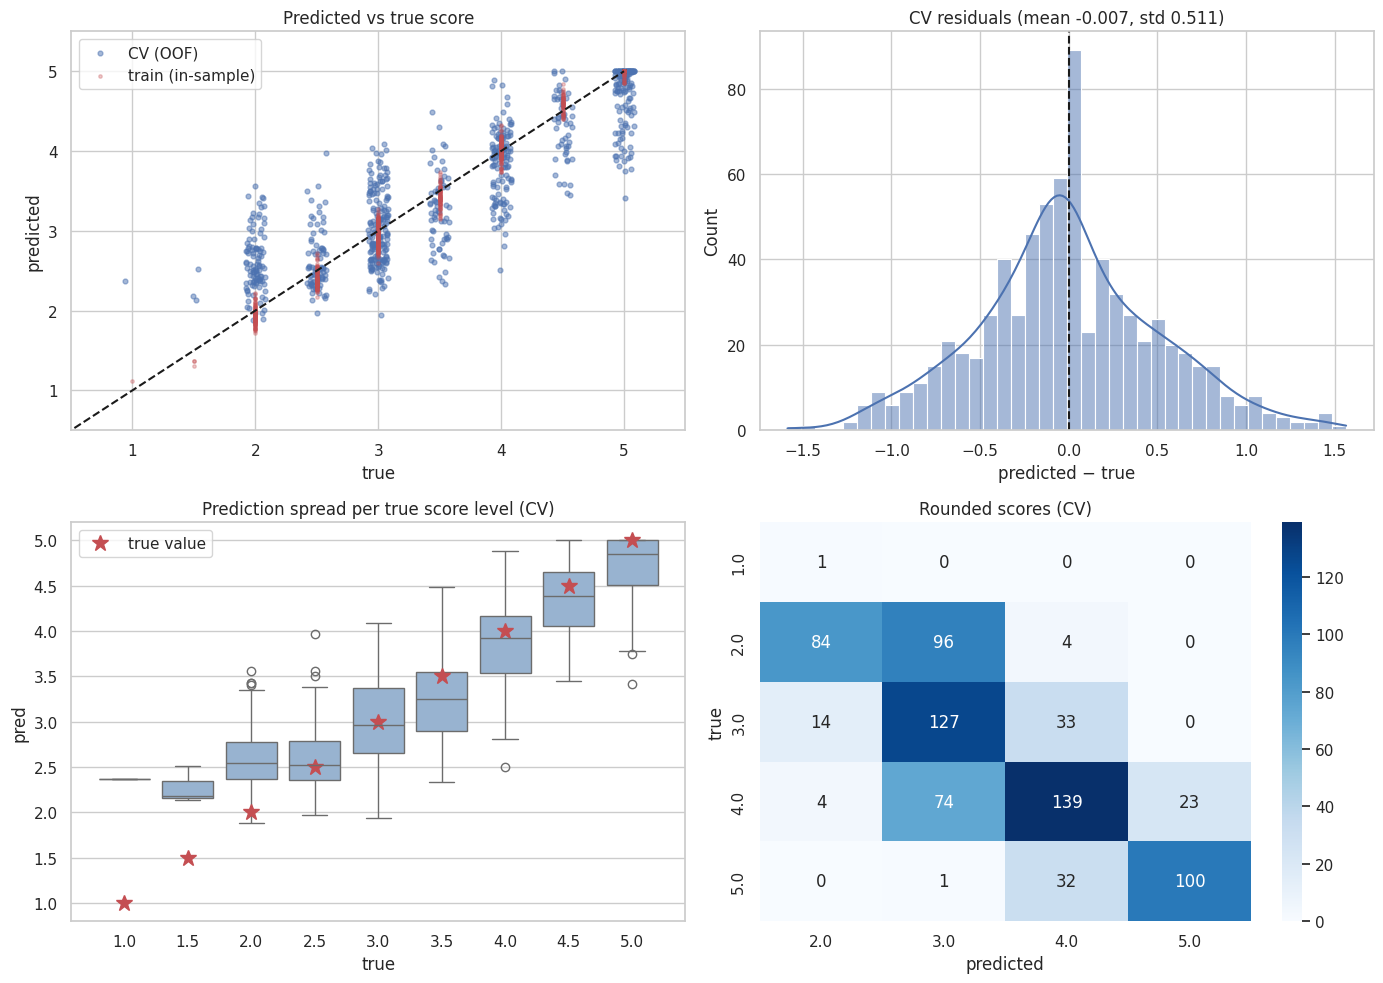

Mean absolute error by score level (CV):
true     1.0    1.5      2.0     2.5      3.0     3.5      4.0     4.5  \
count  1.000  3.000  102.000  79.000  174.000  64.000  124.000  52.000   
mean   1.371  0.778    0.614   0.284    0.372   0.434    0.353   0.356   

true       5.0  
count  133.000  
mean     0.308  


In [29]:
fig, ax = plt.subplots(2, 2, figsize=(14, 10))
# (a) predicted vs true (OOF)
ax[0, 0].scatter(y + np.random.uniform(-0.08, 0.08, len(y)), oof_final, s=12, alpha=0.5, label="CV (OOF)")
ax[0, 0].scatter(y, train_pred_fit, s=6, alpha=0.3, color="#c44e52", label="train (in-sample)")
ax[0, 0].plot([0, 5], [0, 5], "k--"); ax[0, 0].legend()
ax[0, 0].set(title="Predicted vs true score", xlabel="true", ylabel="predicted", xlim=(0.5, 5.5), ylim=(0.5, 5.5))
# (b) residual distribution
res_ = oof_final - y
sns.histplot(res_, bins=40, kde=True, ax=ax[0, 1]); ax[0, 1].axvline(0, color="k", ls="--")
ax[0, 1].set(title=f"CV residuals (mean {res_.mean():+.3f}, std {res_.std():.3f})", xlabel="predicted − true")
# (c) error by true score level
dfe = pd.DataFrame({"true": y, "abs_err": np.abs(res_), "pred": oof_final})
sns.boxplot(data=dfe, x="true", y="pred", ax=ax[1, 0], color="#8fb3d9")
ax[1, 0].plot(range(len(np.unique(y))), np.unique(y), "r*", ms=12, label="true value"); ax[1, 0].legend()
ax[1, 0].set(title="Prediction spread per true score level (CV)")
# (d) confusion matrix of rounded scores
cm = pd.crosstab(pd.Series(np.round(y), name="true"), pd.Series(np.clip(np.round(oof_final), 1, 5), name="predicted"))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax[1, 1]); ax[1, 1].set(title="Rounded scores (CV)")
plt.tight_layout(); plt.show()
print("Mean absolute error by score level (CV):"); print(dfe.groupby("true").abs_err.agg(["count", "mean"]).round(3).T)

### 10.2 Error analysis
Typical behaviour of regression on an imbalanced, bounded scale: predictions are **pulled towards the middle** — the highest
scores are slightly under-predicted and the rare low scores (1–2) over-predicted. The worst errors (listed below) usually
come from very short / quiet responses or ASR failures, where both the transcript and the audio features are unreliable.

In [30]:
worst = pd.DataFrame({"filename": all_df.filename[FIT].values, "true": y, "pred": oof_final.round(2),
                      "n_words": HAND.n_words[FIT].values, "text": all_df.text[FIT].str[:120].values})
worst["err"] = (worst.pred - worst.true).round(2)
worst.reindex(worst.err.abs().sort_values(ascending=False).index).head(8)

,filename,true,pred,n_words,text,err
342,audio_555.wav,5.0,3.41,126,I'm going to describe the scene of a crowded m...,-1.59
559,audio_290.wav,2.0,3.56,25,"This goal is important to me, um, the challeng...",1.56
438,audio_238.wav,4.0,2.51,32,The playground has many children. There are ma...,-1.49
36,audio_170.wav,2.5,3.97,153,I think the goal that I am achieving right now...,1.47
74,audio_482.wav,2.0,3.43,137,My favorite hobby is listening to songs. Of co...,1.43
243,audio_481.wav,2.0,3.43,103,The school playground is a vibrant space teemi...,1.43
437,audio_15.wav,2.0,3.41,80,"Well, first of all, I have a very nice flight....",1.41
399,audio_108.wav,1.0,2.37,139,"As a young child, one of the most exciting pla...",1.37


## 11. Test predictions & submission
Test predictions = non-negative stack of the base models (each averaged over 15 fold models), calibrated with the
calibrator chosen in Section 8.1 and clipped to [1, 5]; test clips of known speakers get the speaker prior
(Section 9.1); clips flagged by the zero-score detector are set to 0. Rows follow **`test.csv`** (216 files).

The file is written to `/kaggle/working/submission.csv`, read back and checked (columns, 216 rows, same filenames as
`test.csv`, labels in [0, 5]). After **Save & Run All (Commit)** it is listed in the version's **Output** tab, with a
**Submit** button.

✅ submission saved and verified: /kaggle/working/submission.csv (216 rows)
files in output folder: {'submission.csv': '4.4 kB'}


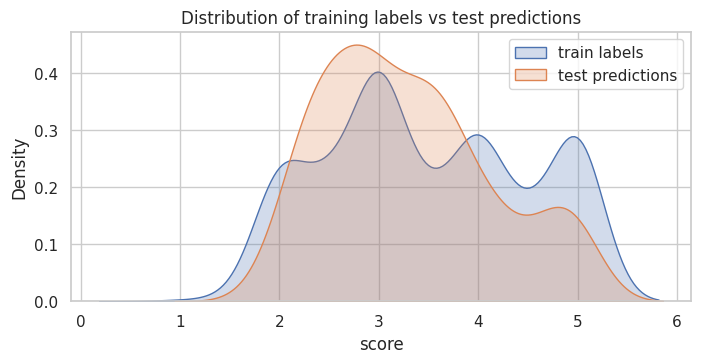

,filename,label
0,audio_128.wav,2.8925
1,audio_156.wav,3.9506
2,audio_19.wav,4.5942
3,audio_108.wav,2.0462
4,audio_206.wav,2.0749


In [31]:
test_pred = finalize(stacker.predict(TEST_PRED[ALL].values))
test_pred[test_known] = (1 - SPK_W) * test_pred[test_known] + SPK_W * test_spk_mean[test_known]   # speaker prior
test_pred[p_zero_test > ZERO_T] = 0.0
submission = pd.DataFrame({"filename": all_df.filename[TE].values, "label": test_pred.round(4)})

# Save to the output folder (/kaggle/working → the version's Output tab), then read it back and verify
SUBMISSION_PATH = os.path.join(OUT_DIR, "submission.csv")
submission.to_csv(SUBMISSION_PATH, index=False)

saved = pd.read_csv(SUBMISSION_PATH)
assert list(saved.columns) == ["filename", "label"], "wrong columns"
assert len(saved) == len(test_df) == 216, f"expected 216 rows, got {len(saved)}"
assert set(saved.filename) == set(test_df.filename), "filenames differ from test.csv"
assert saved.label.notna().all() and saved.label.between(0, 5).all(), "labels must be in [0, 5]"
print(f"✅ submission saved and verified: {SUBMISSION_PATH} ({len(saved)} rows)")
print("files in output folder:", {f: f"{os.path.getsize(os.path.join(OUT_DIR, f)) / 1e3:.1f} kB"
                                  for f in sorted(os.listdir(OUT_DIR)) if os.path.isfile(os.path.join(OUT_DIR, f))})

fig, ax = plt.subplots(figsize=(8, 3.5))
sns.kdeplot(y, label="train labels", fill=True, ax=ax); sns.kdeplot(test_pred[test_pred > 0], label="test predictions", fill=True, ax=ax)
ax.set(title="Distribution of training labels vs test predictions", xlabel="score"); ax.legend(); plt.show()
submission.head()

## 12. Results summary

In [32]:
print("=" * 72)
print(f" ★ TRAINING RMSE (in-sample, all {len(y_all)} training clips): {TRAIN_RMSE:.4f}")
S_ = summary.RMSE
print(f"   TRAINING Pearson:                                    {summary.loc['TRAIN (in-sample), all 769 clips', 'Pearson']:.4f}")
print(f" ★ CV RMSE  (speaker-grouped 5-fold × 3, all clips):     {CV_ALL.RMSE:.4f}")
print(f"   CV Pearson:                                          {CV_ALL.Pearson:.4f}")
print(f"   CV RMSE scored clips (after / before calibration):   {S_['CV (out-of-fold), 732 scored clips']:.4f} / "
      f"{S_['CV scored clips, before calibration']:.4f}  [{CALIB}]")
print(f"   Baseline (predict mean) RMSE:                        {S_['Baseline: predict mean (CV)']:.4f}")
print("=" * 72)
print(f"   Speaker prior: w = {SPK_W:.2f}; RMSE on {known.sum()} repeated-speaker clips {spk_curve[0]:.4f} → "
      f"{spk_curve.min():.4f}; applied to {test_known.sum()} test clips")
print("=" * 72)
print("Models:", {k: CFG[k] for k in ["asr_model", "wavlm", "whisper_enc", "w2vbert", "text_enc", "text_llm",
                                      "judge_llm", "gec", "ctc"]},
      "| audio LLM:", CFG["audio_llm"] if "audiollm" in EMB else "not used")
print("Layers (best layer, ±window):", LAYER_SPEC, "| SVR C:", SVR_C, "| stacker:", STACKER)
display(ablation.round(4))

 ★ TRAINING RMSE (in-sample, all 769 training clips): 0.1223
   TRAINING Pearson:                                    0.9959
 ★ CV RMSE  (speaker-grouped 5-fold × 3, all clips):     0.4983
   CV Pearson:                                          0.9155
   CV RMSE scored clips (after / before calibration):   0.5108 / 0.5108  [none]
   Baseline (predict mean) RMSE:                        1.0137
   Speaker prior: w = 0.45; RMSE on 440 repeated-speaker clips 0.4943 → 0.4204; applied to 25 test clips
Models: {'asr_model': 'large-v3', 'wavlm': 'microsoft/wavlm-large', 'whisper_enc': 'openai/whisper-large-v3', 'w2vbert': 'facebook/w2v-bert-2.0', 'text_enc': 'roberta-large', 'text_llm': 'Qwen/Qwen2.5-7B-Instruct', 'judge_llm': 'Qwen/Qwen3-14B', 'gec': 'grammarly/coedit-large', 'ctc': 'facebook/wav2vec2-large-960h-lv60-self'} | audio LLM: Qwen/Qwen2-Audio-7B-Instruct
Layers (best layer, ±window): {'wavlm': (19, 0), 'whisper': (32, 2), 'text': (19, 1), 'w2vbert': (12, 0), 'textllm': (19, 1), 'judg

,RMSE,MAE,Pearson,Spearman,within_0_5
handcrafted + judges + GEC,0.6293,0.4893,0.7840,0.7740,0.6093
text views (RoBERTa + LLMs),0.5713,0.4498,0.8261,0.8212,0.6516
text + handcrafted (ASR-based),0.5637,0.4403,0.8312,0.8249,0.6585
audio views only,0.5413,0.4100,0.8456,0.8311,0.6694
all views except text LLM,0.5105,0.3889,0.8640,0.8534,0.6858
all views except w2v-BERT,0.5112,0.3900,0.8636,0.8531,0.6831
all views except audio LLM,0.5132,0.3921,0.8625,0.8518,0.6831
all views except Qwen3 judge,0.5128,0.3890,0.8627,0.8522,0.6926
"all views, no ordinal heads",0.5162,0.3945,0.8608,0.8532,0.6721
"all views, no KNN heads",0.5077,0.3865,0.8656,0.8551,0.6913


### Conclusions
1. **Audio views carry the most signal.** Self-supervised speech encoders (WavLM, Whisper encoder, w2v-BERT 2.0) and the
   speech LLM capture fluency, hesitation and lexical/syntactic content at once and are robust to ASR mistakes,
   consistent with Bannò & Matassoni (2022) and Ma et al. (2025).
2. **The LLM judges and the GEC model bring the rubric into the model.** Reading the transcript against the official
   rubric (with scored anchors for Qwen3) and counting the corrections a GEC model makes give grammar-specific signals that
   audio encoders lack; the ablation table shows their contribution.
3. **Text and handcrafted features are complementary and interpretable**: CoLA acceptability, LM surprisal, error rates and
   the judge's probabilities show the model is driven by rubric-relevant cues.
4. **Validation design matters as much as the model.** Separating the zero-score batch, speaker-grouped folds and repeated
   CV give an honest estimate; the gap between training RMSE and CV RMSE is the expected over-fitting of
   high-dimensional embeddings, which strong regularisation keeps under control.
5. **Speaker information is used only where it is legitimate**: CV never mixes speakers, while for test clips of speakers
   already in the training data the speaker prior uses their known scores with a weight estimated on training data.
6. **Limitations / next steps:** fine-tuning the encoders or the speech LLM (e.g. LoRA) instead of using frozen features,
   and test-time augmentation, would likely help further but need more compute.

### References
* Bannò & Matassoni (2022). *Proficiency assessment of L2 spoken English using wav2vec 2.0.* arXiv:2210.13168
* Ma et al. (2025). *Assessment of L2 Oral Proficiency using Speech Large Language Models.* arXiv:2505.21148
* *Speak & Improve Challenge 2025: Tasks and Baseline Systems.* arXiv:2412.11985
* *The NTNU System at the S&I Challenge 2025 SLA Open Track.* arXiv:2506.05121
* Knill, Gales, Manakul & Caines (2019). *Automatic grammatical error detection of non-native spoken learner English.* ICASSP
* *Towards End-to-End Spoken Grammatical Error Correction.* arXiv:2311.05550
* *The Impact of ASR on the Automatic Analysis of Linguistic Complexity in L2 Speech.* arXiv:2104.08529
* *Automated Speech Scoring System Under The Lens.* arXiv:2111.15156
* Chen et al. (2022). *WavLM: Large-Scale Self-Supervised Pre-Training for Full Stack Speech Processing.*
* Radford et al. (2022). *Robust Speech Recognition via Large-Scale Weak Supervision (Whisper).*
* Seamless Communication et al. (2023). *Seamless: Multilingual Expressive and Streaming Speech Translation* (w2v-BERT 2.0 encoder).
* Qwen Team (2024). *Qwen2.5 Technical Report.* arXiv:2412.15115
* Qwen Team (2025). *Qwen3 Technical Report.* arXiv:2505.09388
* Raheja et al. (2023). *CoEdIT: Text Editing by Task-Specific Instruction Tuning.* arXiv:2305.09857
* Caruana, Niculescu-Mizil, Crew & Ksikes (2004). *Ensemble Selection from Libraries of Models.* ICML
* Baevski et al. (2020). *wav2vec 2.0: A Framework for Self-Supervised Learning of Speech Representations.*